# Composer Classification using Deep Learning

## University of San Diego – MS in Applied Artificial Intelligence
## Deep Learning Final Project

This notebook implements a complete deep learning pipeline to classify the composer of classical music pieces using MIDI files.

In [1]:
# Import necessary libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add the project root to Python path for proper imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import project modules
from src.utils.config import *
from src.utils.config import ensure_directories
from src.utils.helpers import set_random_seed, plot_class_distribution
from src.preprocessing import MIDILoader, load_midi_dataset, clean_dataset, split_dataset
from src.datasets import prepare_lstm_dataset, prepare_cnn_dataset
from src.models import create_lstm_model, create_cnn_model
from src.training import train_lstm_model, train_cnn_model
from src.evaluation import ModelEvaluator, ModelVisualizer

# Create output directories and set random seed
ensure_directories()
set_random_seed()

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load MIDI dataset and extract metadata
print("Loading MIDI dataset...")
metadata, stats = load_midi_dataset(RAW_DATA_DIR, COMPOSERS, save_metadata=True)

print("\nDataset Statistics:")
print(f"Total files: {stats['total_files']}")
print(f"Valid files: {stats['valid_files']}")
print(f"Invalid files: {stats['invalid_files']}")

print("\nFiles per composer:")
for composer, composer_stats in stats['composers'].items():
    print(f"  {composer}: {composer_stats['total']} files ({composer_stats['valid']} valid)")

Loading MIDI dataset...
Found 131 MIDI files for Bach


Loading Bach:   0%|          | 0/131 [00:00<?, ?it/s]

Loading Bach: 100%|██████████| 131/131 [00:02<00:00, 48.80it/s]


Found 134 MIDI files for Beethoven


Loading Beethoven: 100%|██████████| 134/134 [00:05<00:00, 25.04it/s]


Found 136 MIDI files for Chopin


Loading Chopin: 100%|██████████| 136/136 [00:02<00:00, 49.14it/s]


Found 90 MIDI files for Mozart


Loading Mozart: 100%|██████████| 90/90 [00:02<00:00, 34.81it/s]

Saved metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/metadata.csv

Dataset Statistics:
Total files: 490
Valid files: 490
Invalid files: 0

Files per composer:
  Bach: 131 files (131 valid)
  Beethoven: 133 files (133 valid)
  Chopin: 136 files (136 valid)
  Mozart: 90 files (90 valid)


In [3]:
# TODO: Delete this cell (duplicate of cell above)

In [4]:
# Load metadata from CSV
metadata_df = pd.read_csv(METADATA_FILE)
print(f"Loaded metadata with {len(metadata_df)} entries")
metadata_df.head()

Loaded metadata with 490 entries


,filename,filepath,composer,label,duration,num_notes,tempo,num_instruments,valid
0,Bwv0997 Partita for Lute 1mov.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,166.000000,977,80.000000,2,True
1,Bwv0535 Prelude and Fugue.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,412.770389,3157,80.000000,3,True
2,Bwv0806 English Suite n1 05mov.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,120.250096,1050,143.999885,2,True
3,Bwv0998 Prelude Fugue Allegro for Lute 3mov.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,93.000000,748,100.000000,3,True
4,Jesu Joy of Man Desiring.mid,/Users/5088547/Desktop/AAI_511_Group6_DeepLear...,Bach,0,199.410065,2693,65.000065,11,True


Class Distribution:
Saved class distribution plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/Overall_Class_Distribution.png


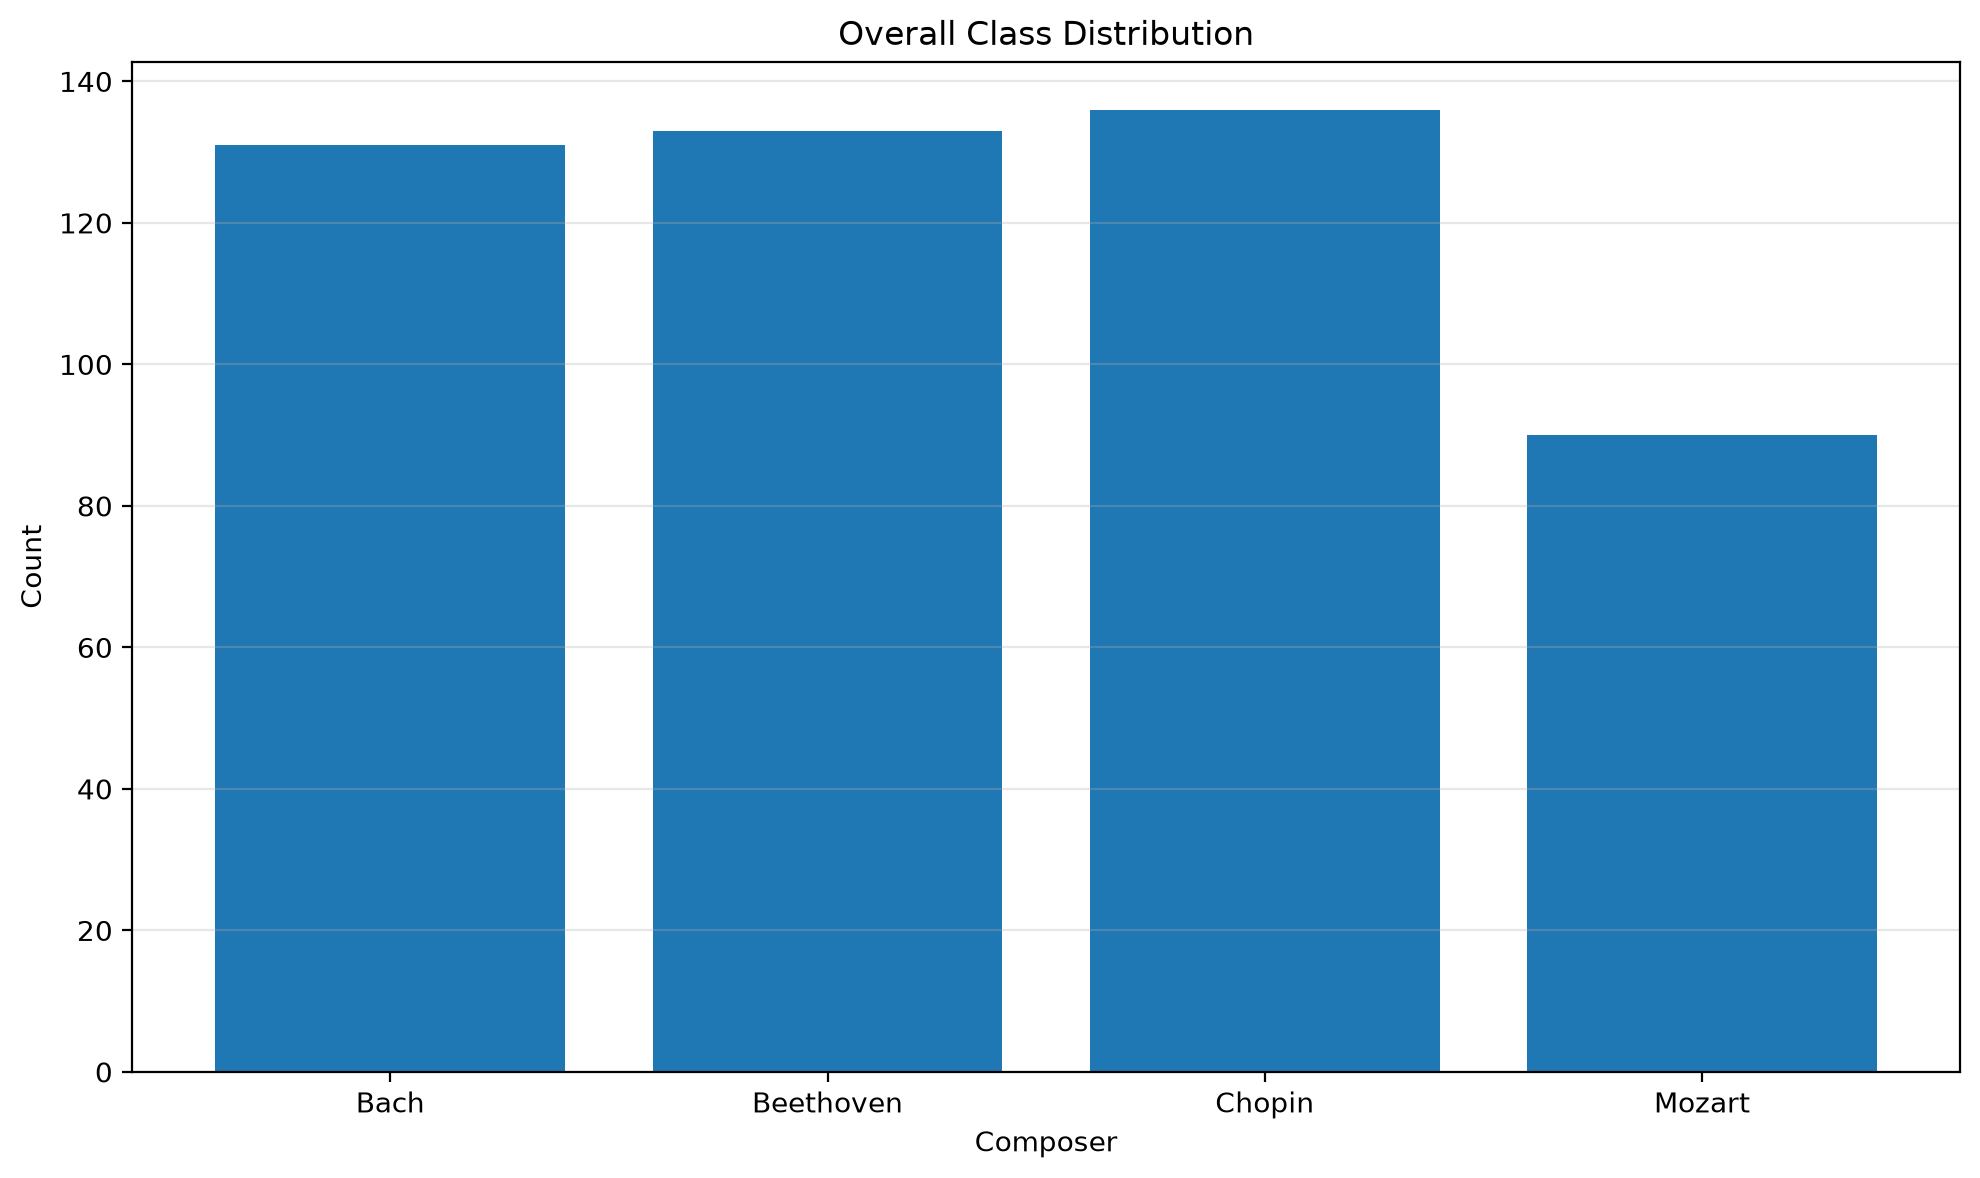

In [5]:
# Exploratory Data Analysis
print("Class Distribution:")
plot_class_distribution(metadata_df['label'].values, COMPOSERS, "Overall Class Distribution")

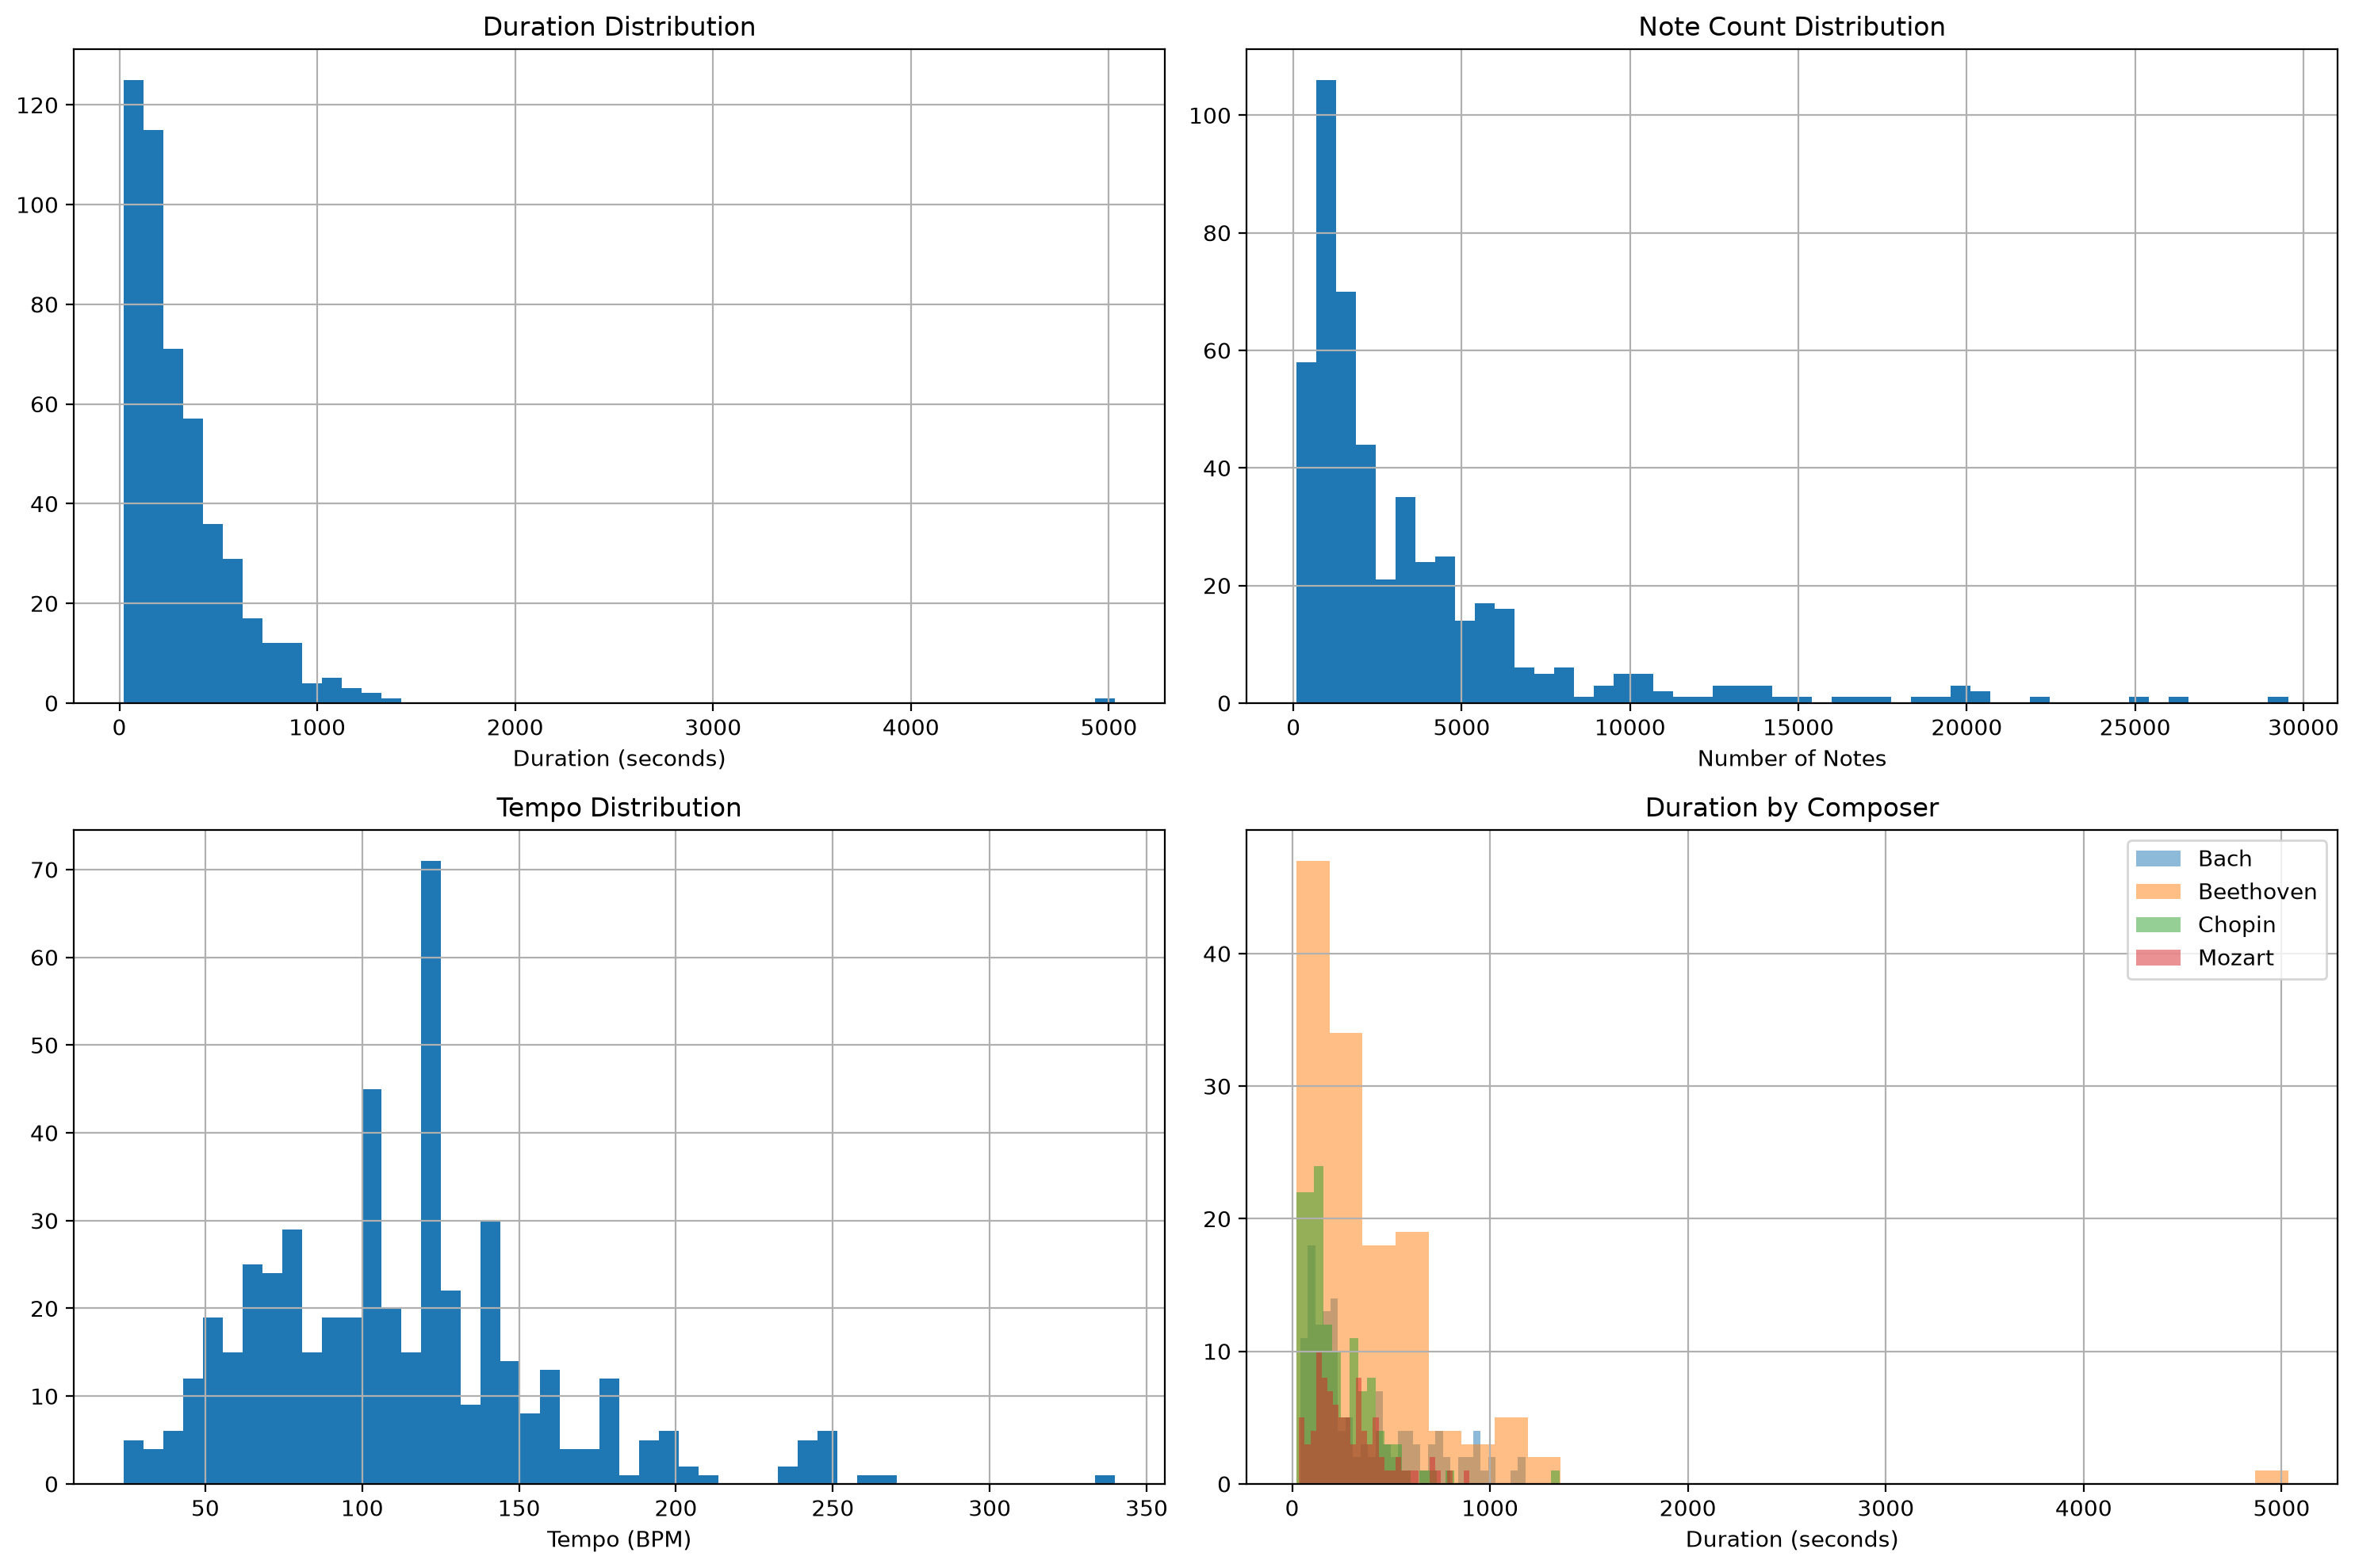

In [6]:
# Feature distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Duration distribution
metadata_df['duration'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Duration Distribution')
axes[0,0].set_xlabel('Duration (seconds)')

# Note count distribution
metadata_df['num_notes'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Note Count Distribution')
axes[0,1].set_xlabel('Number of Notes')

# Tempo distribution
metadata_df['tempo'].hist(bins=50, ax=axes[1,0])
axes[1,0].set_title('Tempo Distribution')
axes[1,0].set_xlabel('Tempo (BPM)')

# Duration by composer
for composer in COMPOSERS:
    composer_data = metadata_df[metadata_df['composer'] == composer]['duration']
    composer_data.hist(bins=30, alpha=0.5, label=composer, ax=axes[1,1])
axes[1,1].set_title('Duration by Composer')
axes[1,1].set_xlabel('Duration (seconds)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_distributions.png', dpi=FIGURE_DPI)
plt.show()

## 3. Data Preprocessing and Cleaning

In [7]:
# Clean dataset
print("Cleaning dataset...")
cleaned_df = clean_dataset(
    metadata_path=METADATA_FILE,
    min_notes=MIN_NOTES,
    min_duration=1.0,
    max_duration=600.0,
    balance=True,
    balance_method='undersample',
    output_path=INTERIM_DATA_DIR / 'cleaned_metadata.csv'
)

print(f"\nCleaned dataset: {len(cleaned_df)} files")

Cleaning dataset...
Starting dataset cleaning...
Original dataset: 490 files
Filtered 0 files with < 10 notes
Retained 490 valid files
Filtered 65 files with duration outside [1.0, 600.0] seconds
Retained 425 valid files
Filtered 0 files from non-specified composers
Retained 425 files from specified composers
Removed 0 duplicate files
Retained 425 unique files


Validating files: 100%|██████████| 425/425 [00:00<00:00, 54604.97it/s]

Found 0 missing files
Retained 425 existing files
Balanced dataset: 336 total files
Samples per composer:
composer
Bach         84
Beethoven    84
Chopin       84
Mozart       84
Name: count, dtype: int64

Cleaning Report:
Original files: 490
Valid files: 336
Invalid files: 65
Files per composer:
  Bach: 84
  Beethoven: 84
  Chopin: 84
  Mozart: 84
Saved cleaned metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/cleaned_metadata.csv

Cleaned dataset: 336 files


In [8]:
# Split dataset into train/val/test
print("Splitting dataset...")
train_df, val_df, test_df = split_dataset(
    cleaned_df,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
    stratified=True,
    output_dir=INTERIM_DATA_DIR
)

print(f"Training set: {len(train_df)} files")
print(f"Validation set: {len(val_df)} files")
print(f"Test set: {len(test_df)} files")

Splitting dataset...

Dataset Split Statistics:

Training Set:
  Total: 268 files
  Percentage: 79.8%
  Composers:
    Bach: 67 (25.0%)
    Beethoven: 67 (25.0%)
    Chopin: 67 (25.0%)
    Mozart: 67 (25.0%)

Validation Set:
  Total: 34 files
  Percentage: 10.1%
  Composers:
    Bach: 8 (23.5%)
    Beethoven: 9 (26.5%)
    Chopin: 8 (23.5%)
    Mozart: 9 (26.5%)

Test Set:
  Total: 34 files
  Percentage: 10.1%
  Composers:
    Bach: 9 (26.5%)
    Beethoven: 8 (23.5%)
    Chopin: 9 (26.5%)
    Mozart: 8 (23.5%)
Saved training metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/train_metadata.csv
Saved validation metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/val_metadata.csv
Saved test metadata to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/interim/

## 4. Feature Extraction and Dataset Preparation

In [9]:
# Prepare LSTM dataset
print("Preparing LSTM dataset...")
X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, X_test_lstm, y_test_lstm = prepare_lstm_dataset(
    train_df, val_df, test_df,
    feature_type='combined',
    sequence_length=SEQUENCE_LENGTH,
    normalize=True,
    save_path=LSTM_FEATURES_FILE
)

print(f"LSTM training data shape: {X_train_lstm.shape}")
print(f"LSTM validation data shape: {X_val_lstm.shape}")
print(f"LSTM test data shape: {X_test_lstm.shape}")

Preparing LSTM dataset...
Loading training set...
Loading 268 MIDI files for LSTM dataset...


100%|██████████| 268/268 [00:05<00:00, 48.91it/s]


Loaded 268 samples successfully
Feature shape: (268, 500, 3)
Labels shape: (268,)
Loading validation set...
Loading 34 MIDI files for LSTM dataset...


100%|██████████| 34/34 [00:00<00:00, 49.13it/s]


Loaded 34 samples successfully
Feature shape: (34, 500, 3)
Labels shape: (34,)
Loading test set...
Loading 34 MIDI files for LSTM dataset...


100%|██████████| 34/34 [00:00<00:00, 35.38it/s]

Loaded 34 samples successfully
Feature shape: (34, 500, 3)
Labels shape: (34,)
Saved LSTM dataset to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/features/lstm_features.npz
LSTM training data shape: (268, 500, 3)
LSTM validation data shape: (34, 500, 3)
LSTM test data shape: (34, 500, 3)


In [10]:
# Prepare CNN dataset
print("Preparing CNN dataset...")
X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn, X_test_cnn, y_test_cnn = prepare_cnn_dataset(
    train_df, val_df, test_df,
    roll_type='velocity',
    time_steps=MAX_TIME_STEPS,
    pitch_range=PITCH_RANGE,
    fps=20.0,
    save_path=CNN_FEATURES_FILE
)

print(f"CNN training data shape: {X_train_cnn.shape}")
print(f"CNN validation data shape: {X_val_cnn.shape}")
print(f"CNN test data shape: {X_test_cnn.shape}")

Preparing CNN dataset...
Loading training set...
Loading 268 MIDI files for CNN dataset...


100%|██████████| 268/268 [00:07<00:00, 37.86it/s]


Loaded 268 samples successfully
Feature shape: (268, 128, 1000)
Labels shape: (268,)
Loading validation set...
Loading 34 MIDI files for CNN dataset...


100%|██████████| 34/34 [00:00<00:00, 38.88it/s]


Loaded 34 samples successfully
Feature shape: (34, 128, 1000)
Labels shape: (34,)
Loading test set...
Loading 34 MIDI files for CNN dataset...


100%|██████████| 34/34 [00:01<00:00, 28.98it/s]


Loaded 34 samples successfully
Feature shape: (34, 128, 1000)
Labels shape: (34,)
Saved CNN dataset to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/data/features/cnn_features.npz
CNN training data shape: (268, 128, 1000, 1)
CNN validation data shape: (34, 128, 1000, 1)
CNN test data shape: (34, 128, 1000, 1)


## 5. LSTM Model Training

In [11]:
# Train LSTM model (using default hyperparameters — will be retrained with tuned params later)
print("Training LSTM model...")
lstm_input_shape = X_train_lstm.shape[1:]  # (sequence_length, num_features)

lstm_summary, lstm_metrics = train_lstm_model(
    X_train_lstm, y_train_lstm,
    X_val_lstm, y_val_lstm,
    X_test_lstm, y_test_lstm,
    input_shape=lstm_input_shape,
    num_classes=NUM_CLASSES,
    model_type='standard',
    batch_size=LSTM_BATCH_SIZE,
    epochs=LSTM_EPOCHS
)

print("\nLSTM Training Summary:")
for key, value in lstm_summary.items():
    print(f"  {key}: {value}")

Training LSTM model...


Model: "LSTM_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 256)       │       266,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,964 (3.15 MB)

 Trainable params: 824,964 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Training LSTM model for up to 50 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2910 - loss: 1.3766
Epoch 1: val_accuracy improved from None to 0.35294, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2910 - loss: 1.3766 - val_accuracy: 0.3529 - val_loss: 1.3166 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3545 - loss: 1.3731
Epoch 2: val_accuracy did not improve from 0.35294
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3545 - loss: 1.3731 - val_accuracy: 0.3529 - val_loss: 1.2695 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3209 - loss: 1.3131
Epoch 3: val_accuracy improved from 0.35294 to 0.50000, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 3: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3209 - loss: 1.3131 - val_accuracy: 0.5000 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.3918 - loss: 1.2731
Epoch 4: val_accuracy did not improve from 0.50000
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3918 - loss: 1.2731 - val_accuracy: 0.3529 - val_loss: 1.3068 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4179 - loss: 1.2542
Epoch 5: val_accuracy did not improve from 0.50000
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4179 - loss: 1.2542 - val_accuracy: 0.4118 - val_loss: 1.2611 - learning_rate: 0.0010
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4179 - loss: 1.2288
Epoch 6: val_accuracy did not improve from 0

Training completed in 2m 10s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step
Test Loss: 1.2824
Test Accuracy: 0.4118
Precision: 0.4201
Recall: 0.4118
F1 Score (weighted): 0.4029
F1 Score (macro):    0.3936
Saved final model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_final.h5

LSTM Training Summary:
  epochs_trained: 13
  final_train_loss: 1.1875343322753906
  final_train_accuracy: 0.5111940503120422
  final_val_loss: 1.376662015914917
  final_val_accuracy: 0.44117647409439087
  best_val_accuracy: 0.5
  best_val_loss: 1.2610507011413574
  training_time: 130.57563304901123
  parameters: 824964


## 6. CNN Model Training

In [12]:
# Train CNN model
print("Training CNN model...")
cnn_input_shape = X_train_cnn.shape[1:]  # (pitch_range, time_steps, channels)

cnn_summary, cnn_metrics = train_cnn_model(
    X_train_cnn, y_train_cnn,
    X_val_cnn, y_val_cnn,
    X_test_cnn, y_test_cnn,
    input_shape=cnn_input_shape,
    num_classes=NUM_CLASSES,
    model_type='standard',
    batch_size=CNN_BATCH_SIZE,
    epochs=CNN_EPOCHS
)

print("\nCNN Training Summary:")
for key, value in cnn_summary.items():
    print(f"  {key}: {value}")

Training CNN model...


Model: "CNN_Composer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 1000, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 1000, 64)  │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1000, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 500, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 500, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 500, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 500, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 250, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 250, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 250, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 250, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 125, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 125, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,140 (1.93 MB)

 Trainable params: 505,220 (1.93 MB)

 Non-trainable params: 1,920 (7.50 KB)

Training CNN model for up to 50 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3545 - loss: 1.6989
Epoch 1: val_accuracy improved from None to 0.23529, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.3545 - loss: 1.6989 - val_accuracy: 0.2353 - val_loss: 1.3583 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4739 - loss: 1.3284
Epoch 2: val_accuracy improved from 0.23529 to 0.44118, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5



Epoch 2: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.4739 - loss: 1.3284 - val_accuracy: 0.4412 - val_loss: 1.3591 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5410 - loss: 1.1440
Epoch 3: val_accuracy did not improve from 0.44118
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.5410 - loss: 1.1440 - val_accuracy: 0.2647 - val_loss: 1.4202 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5784 - loss: 1.0311
Epoch 4: val_accuracy did not improve from 0.44118
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.5784 - loss: 1.0311 - val_accuracy: 0.2647 - val_loss: 1.6281 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6455 - loss: 0.9459
Epoch 5: val_accuracy did not improve from 0.44

Training completed in 5m 3s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
Test Loss: 1.3618
Test Accuracy: 0.3824
Precision: 0.2224
Recall: 0.3824
F1 Score (weighted): 0.2611
F1 Score (macro):    0.2601
Saved final model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/cnn_composer_classifier_final.h5

CNN Training Summary:
  epochs_trained: 12
  final_train_loss: 0.6177985668182373
  final_train_accuracy: 0.7686567306518555
  final_val_loss: 5.281357765197754
  final_val_accuracy: 0.2647058963775635
  best_val_accuracy: 0.44117647409439087
  best_val_loss: 1.358283281326294
  training_time: 303.21862030029297
  parameters: 505220


## 7. Model Evaluation

In [13]:
# Load trained models and make predictions
from tensorflow import keras

# Load LSTM model
lstm_model = keras.models.load_model(BEST_LSTM_MODEL)
lstm_pred_proba = lstm_model.predict(X_test_lstm)
lstm_pred = np.argmax(lstm_pred_proba, axis=1)

# Load CNN model
cnn_model = keras.models.load_model(BEST_CNN_MODEL)
cnn_pred_proba = cnn_model.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_pred_proba, axis=1)

print("Predictions generated successfully!")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x15f9b62a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
Predictions generated successfully!


LSTM Model Evaluation:

EVALUATION METRICS
Accuracy:  0.4118
Precision: 0.4201
Recall:    0.4118
F1 Score (weighted): 0.4029
F1 Score (macro):    0.3936
ROC-AUC:   0.6836

Per-Class Metrics:
--------------------------------------------------
Bach:
  Precision: 0.6667
  Recall:    0.4444
  F1 Score:  0.5333
Beethoven:
  Precision: 0.2727
  Recall:    0.3750
  F1 Score:  0.3158
Chopin:
  Precision: 0.5000
  Recall:    0.6667
  F1 Score:  0.5714
Mozart:
  Precision: 0.2000
  Recall:    0.1250
  F1 Score:  0.1538

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        Bach       0.67      0.44      0.53         9
   Beethoven       0.27      0.38      0.32         8
      Chopin       0.50      0.67      0.57         9
      Mozart       0.20      0.12      0.15         8

    accuracy                           0.41        34
   macro avg       0.41      0.40      0.39        34
weighted avg       0.42      0

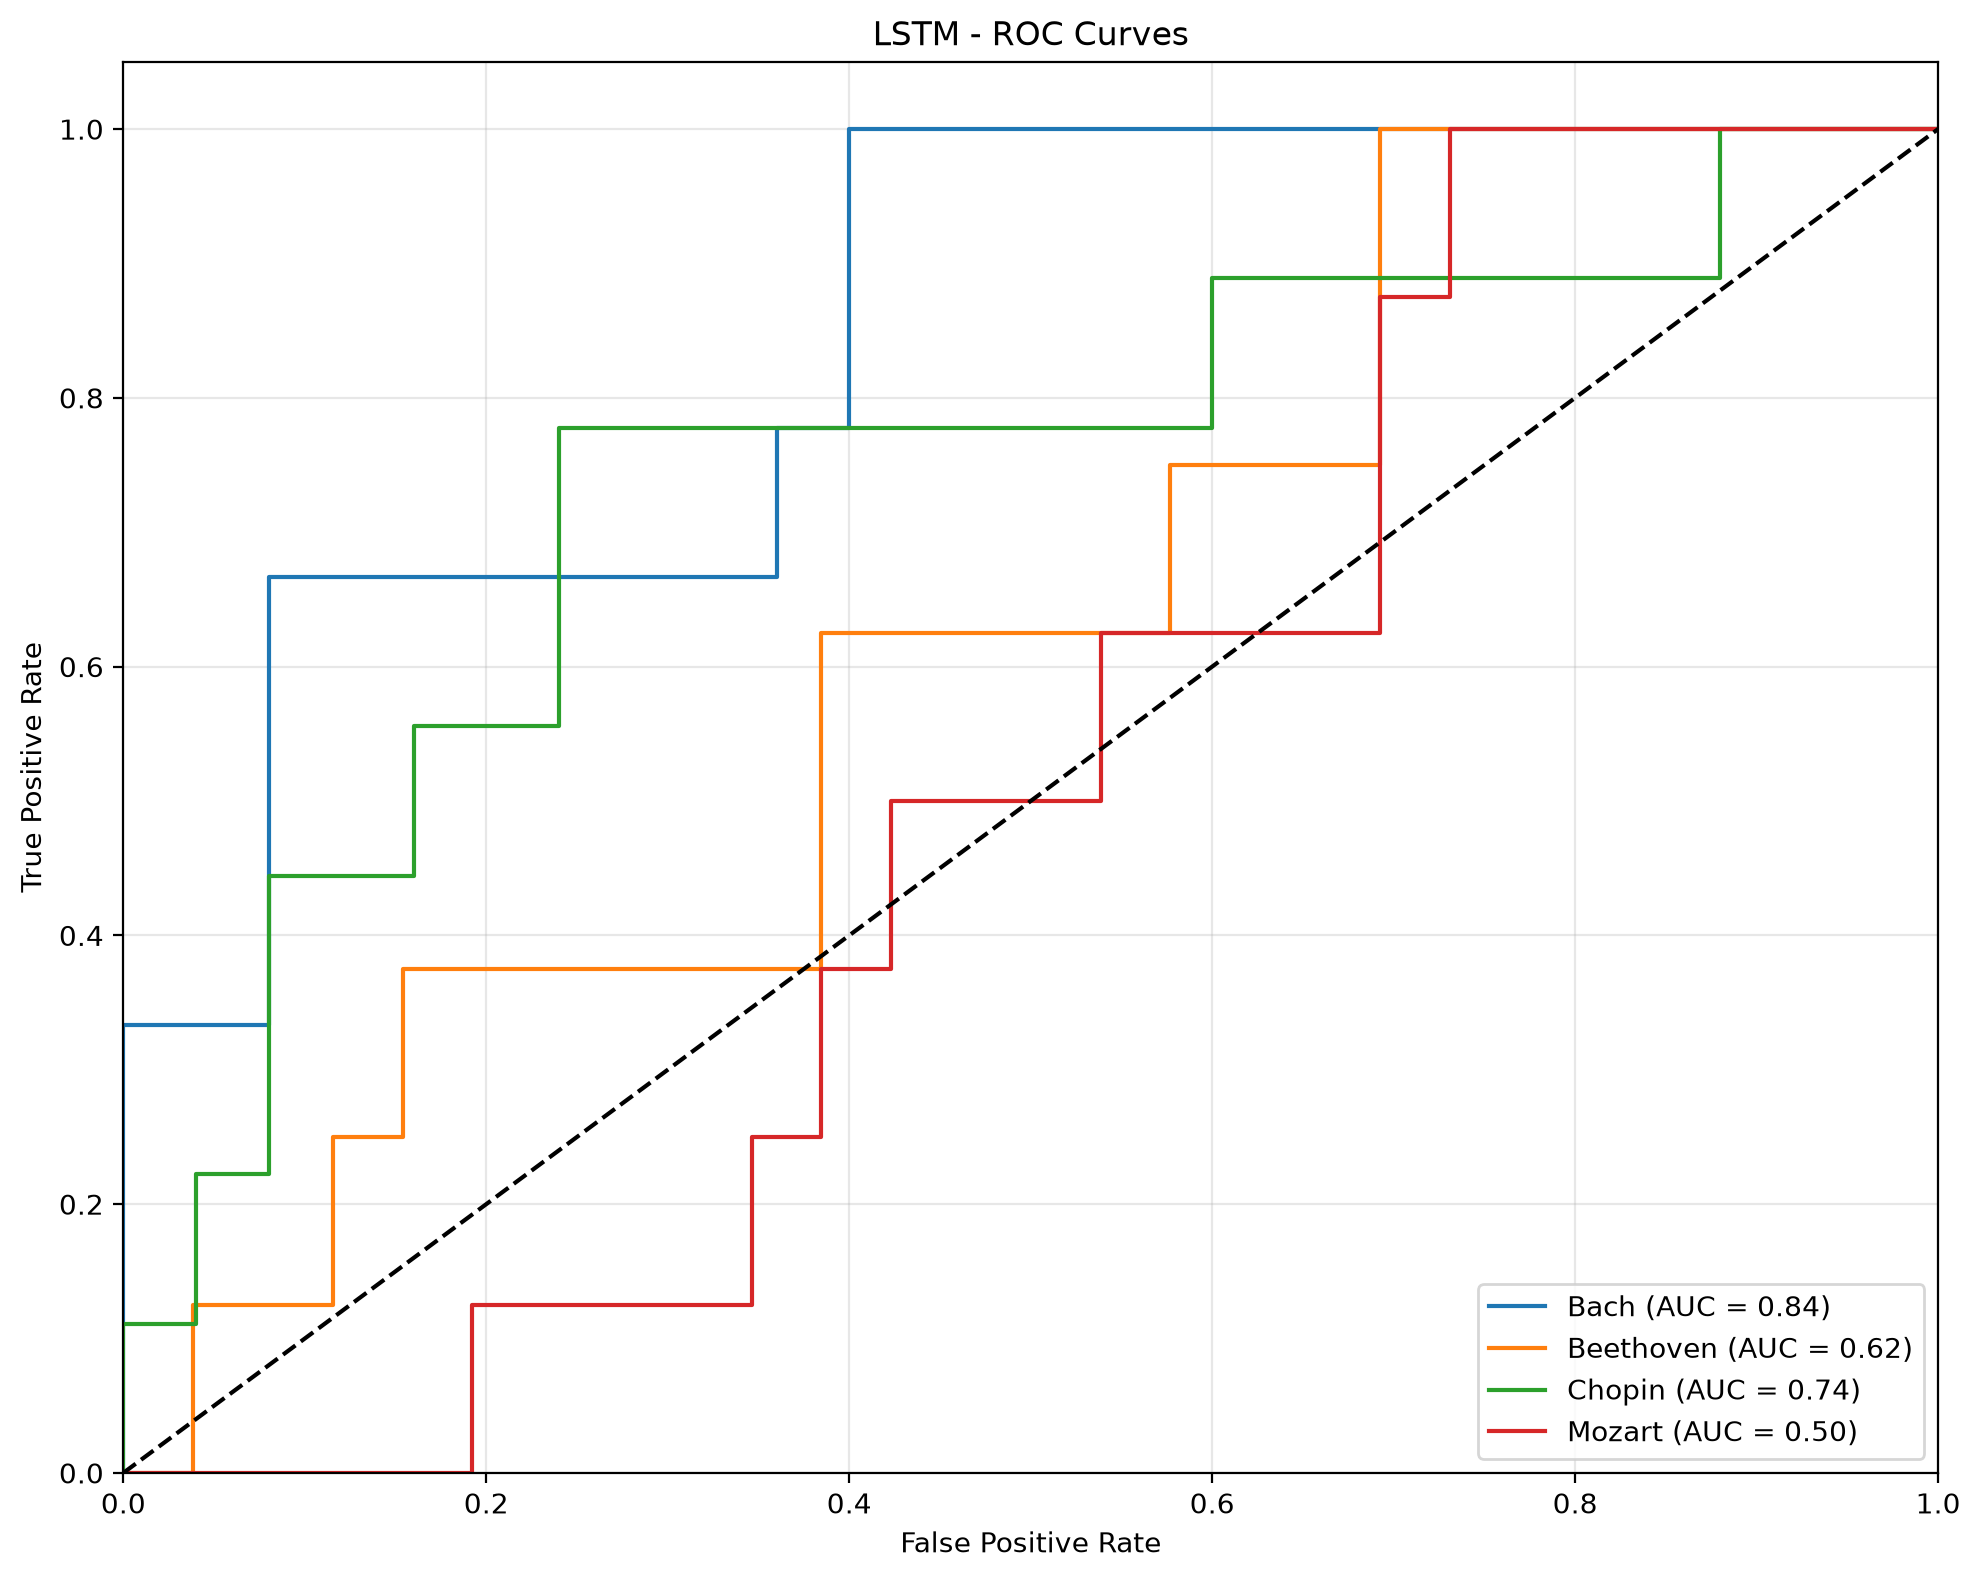

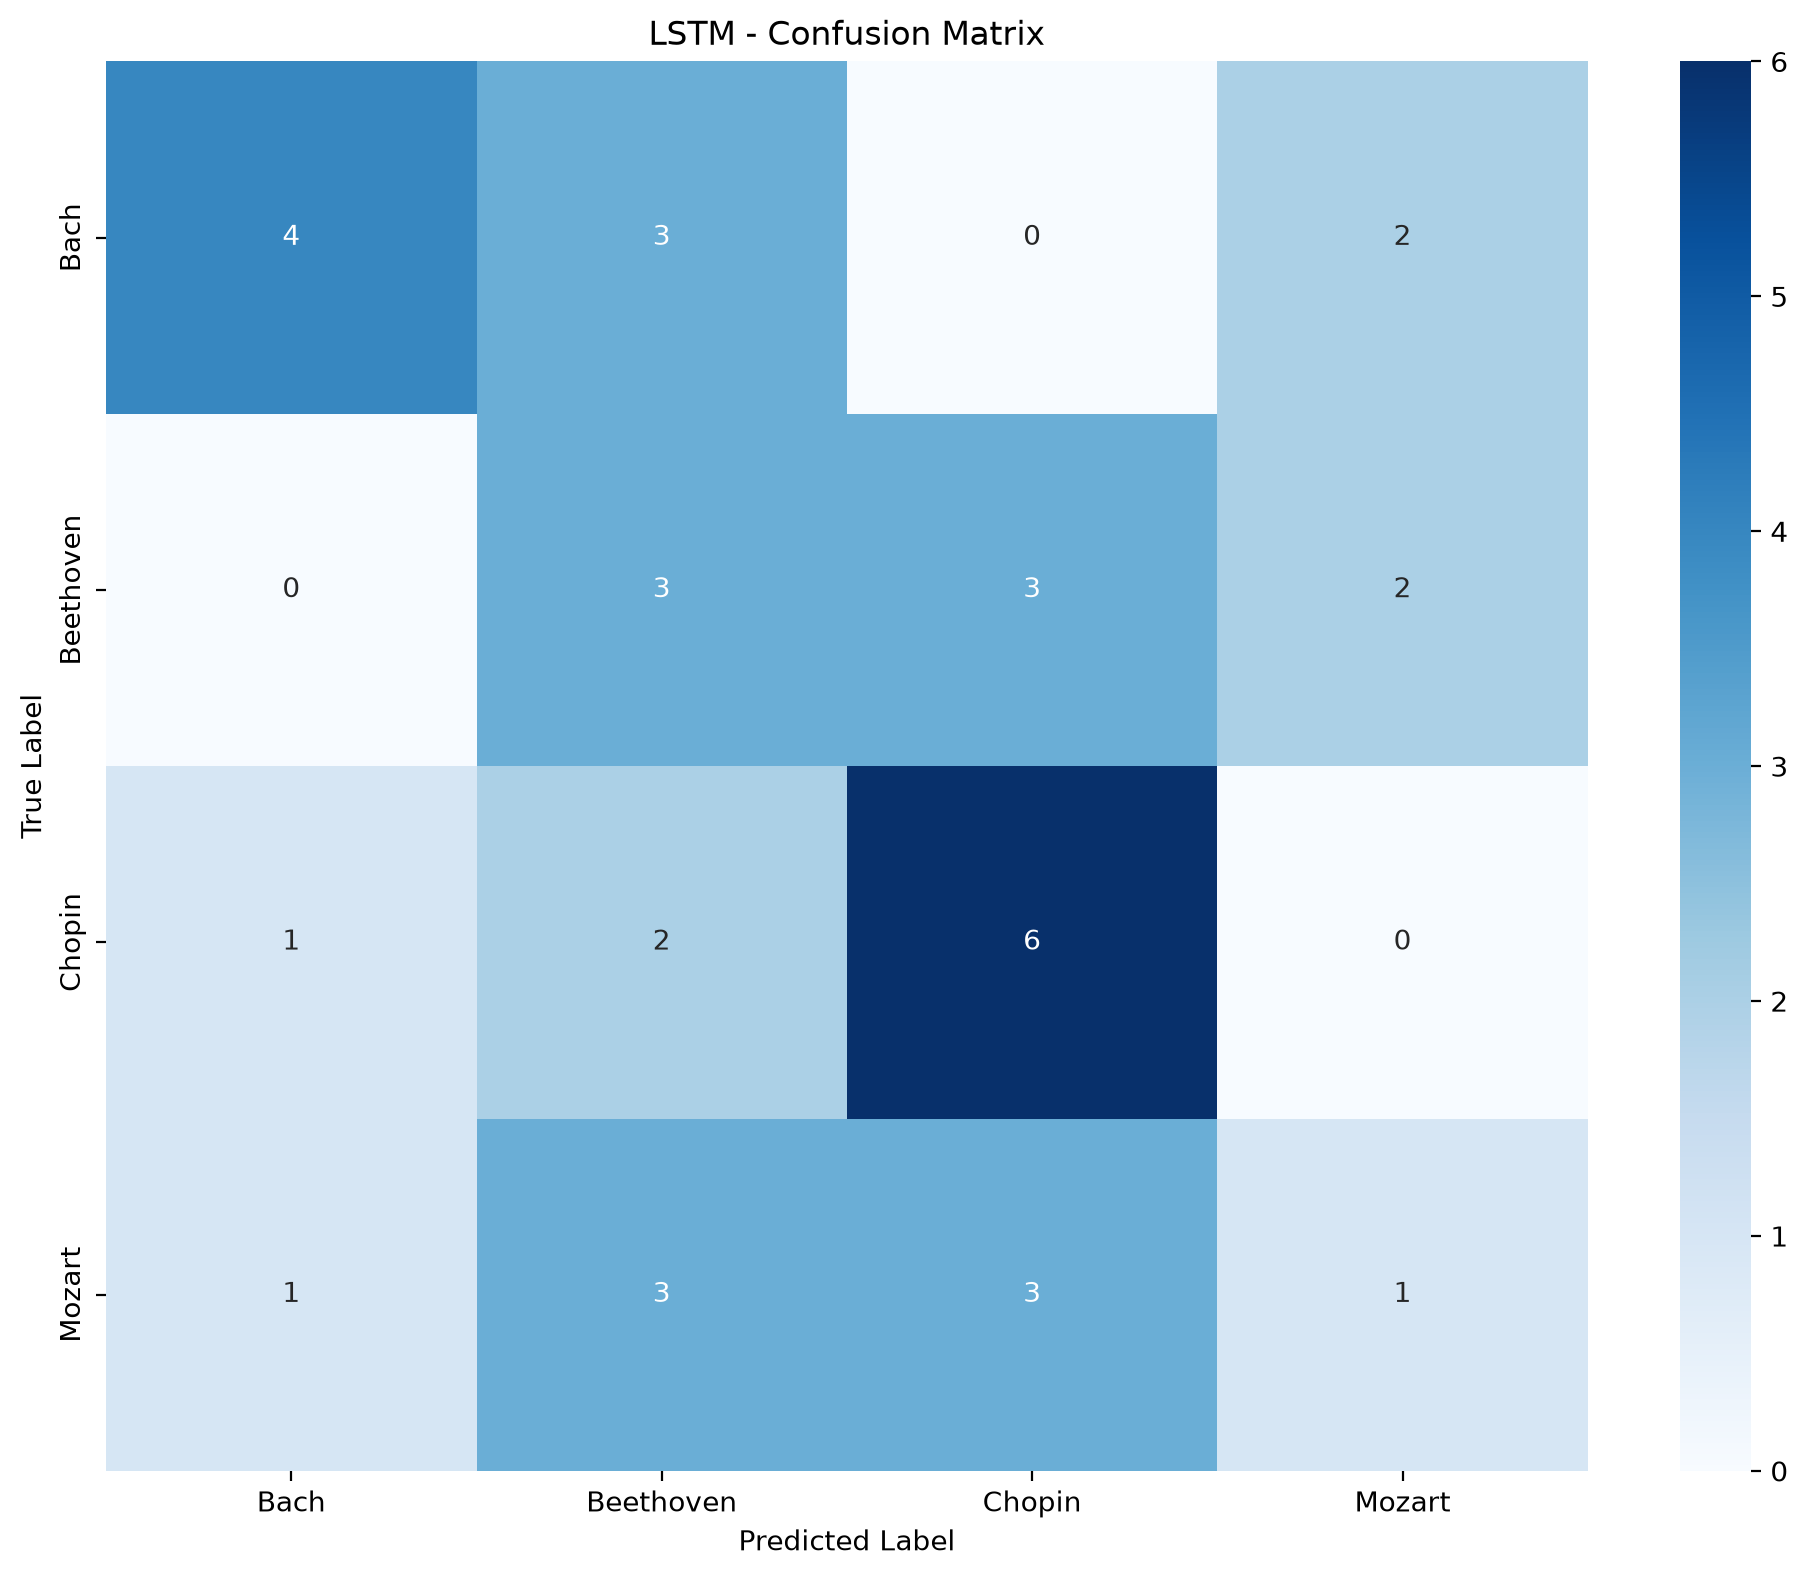

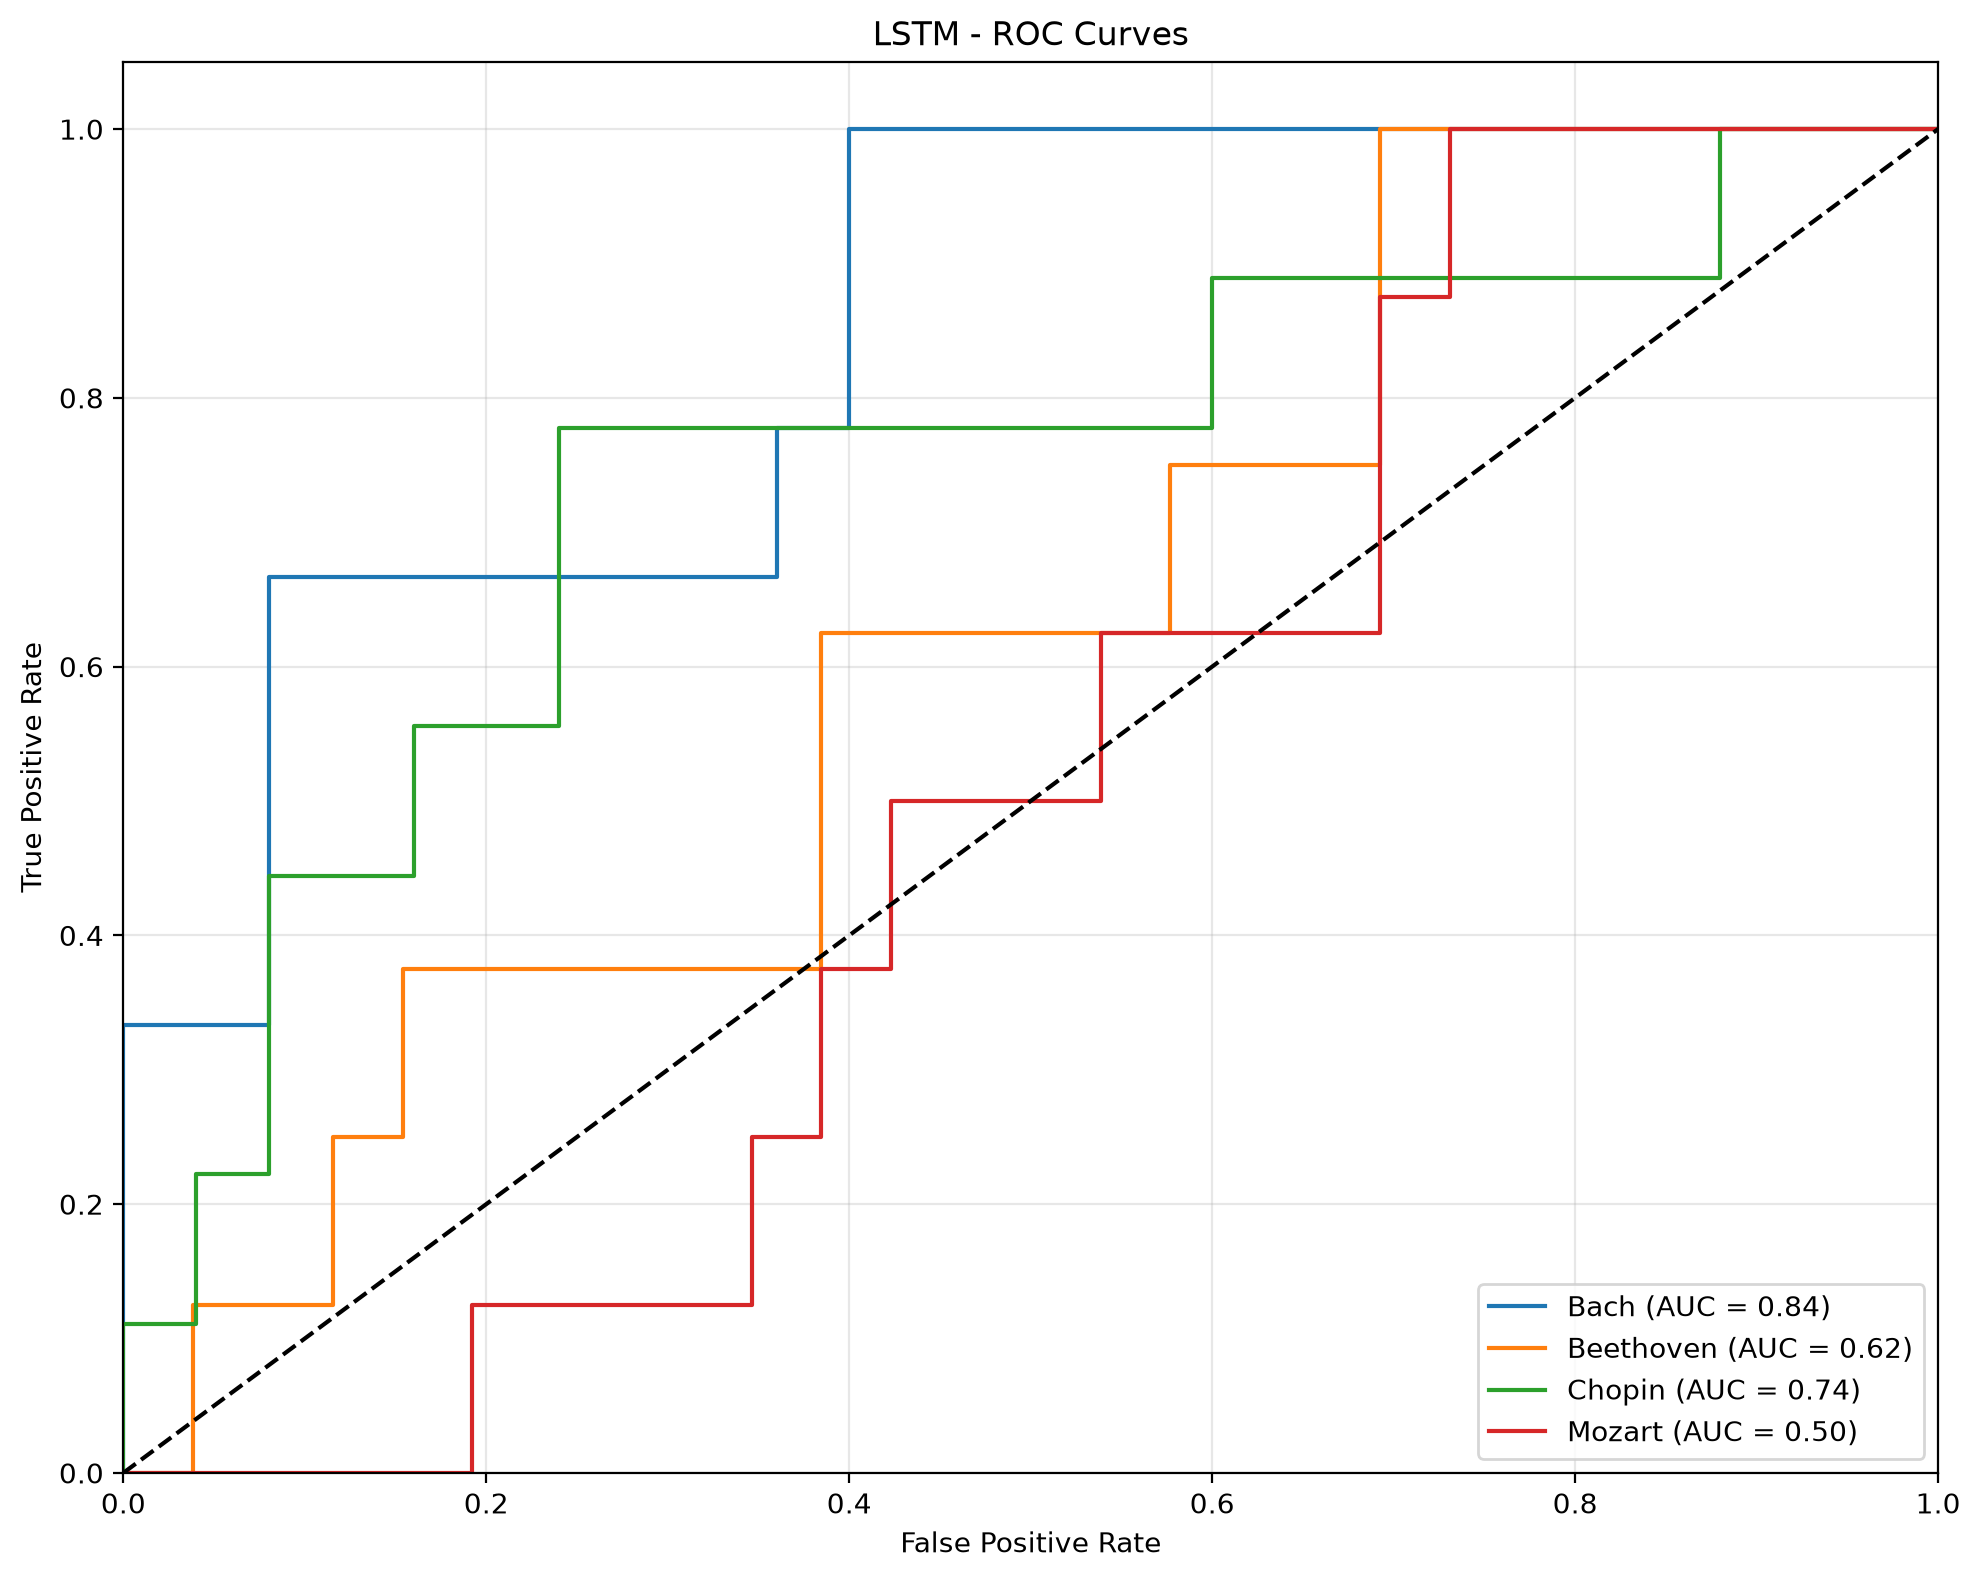

In [14]:
# Evaluate LSTM model
print("LSTM Model Evaluation:")
lstm_evaluator = ModelEvaluator(COMPOSERS)
lstm_metrics = lstm_evaluator.calculate_metrics(y_test_lstm, lstm_pred, lstm_pred_proba)
lstm_evaluator.print_metrics(y_test_lstm, lstm_pred, lstm_pred_proba)
lstm_evaluator.plot_confusion_matrix(y_test_lstm, lstm_pred, "LSTM", save_fig=True)
lstm_evaluator.plot_roc_curves(y_test_lstm, lstm_pred_proba, "LSTM", save_fig=True)

CNN Model Evaluation:

EVALUATION METRICS
Accuracy:  0.3824
Precision: 0.2224
Recall:    0.3824
F1 Score (weighted): 0.2611
F1 Score (macro):    0.2601
ROC-AUC:   0.7180

Per-Class Metrics:
--------------------------------------------------
Bach:
  Precision: 0.5556
  Recall:    0.5556
  F1 Score:  0.5556
Beethoven:
  Precision: 0.3200
  Recall:    1.0000
  F1 Score:  0.4848
Chopin:
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
Mozart:
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        Bach       0.56      0.56      0.56         9
   Beethoven       0.32      1.00      0.48         8
      Chopin       0.00      0.00      0.00         9
      Mozart       0.00      0.00      0.00         8

    accuracy                           0.38        34
   macro avg       0.22      0.39      0.26        34
weighted avg       0.22      0.

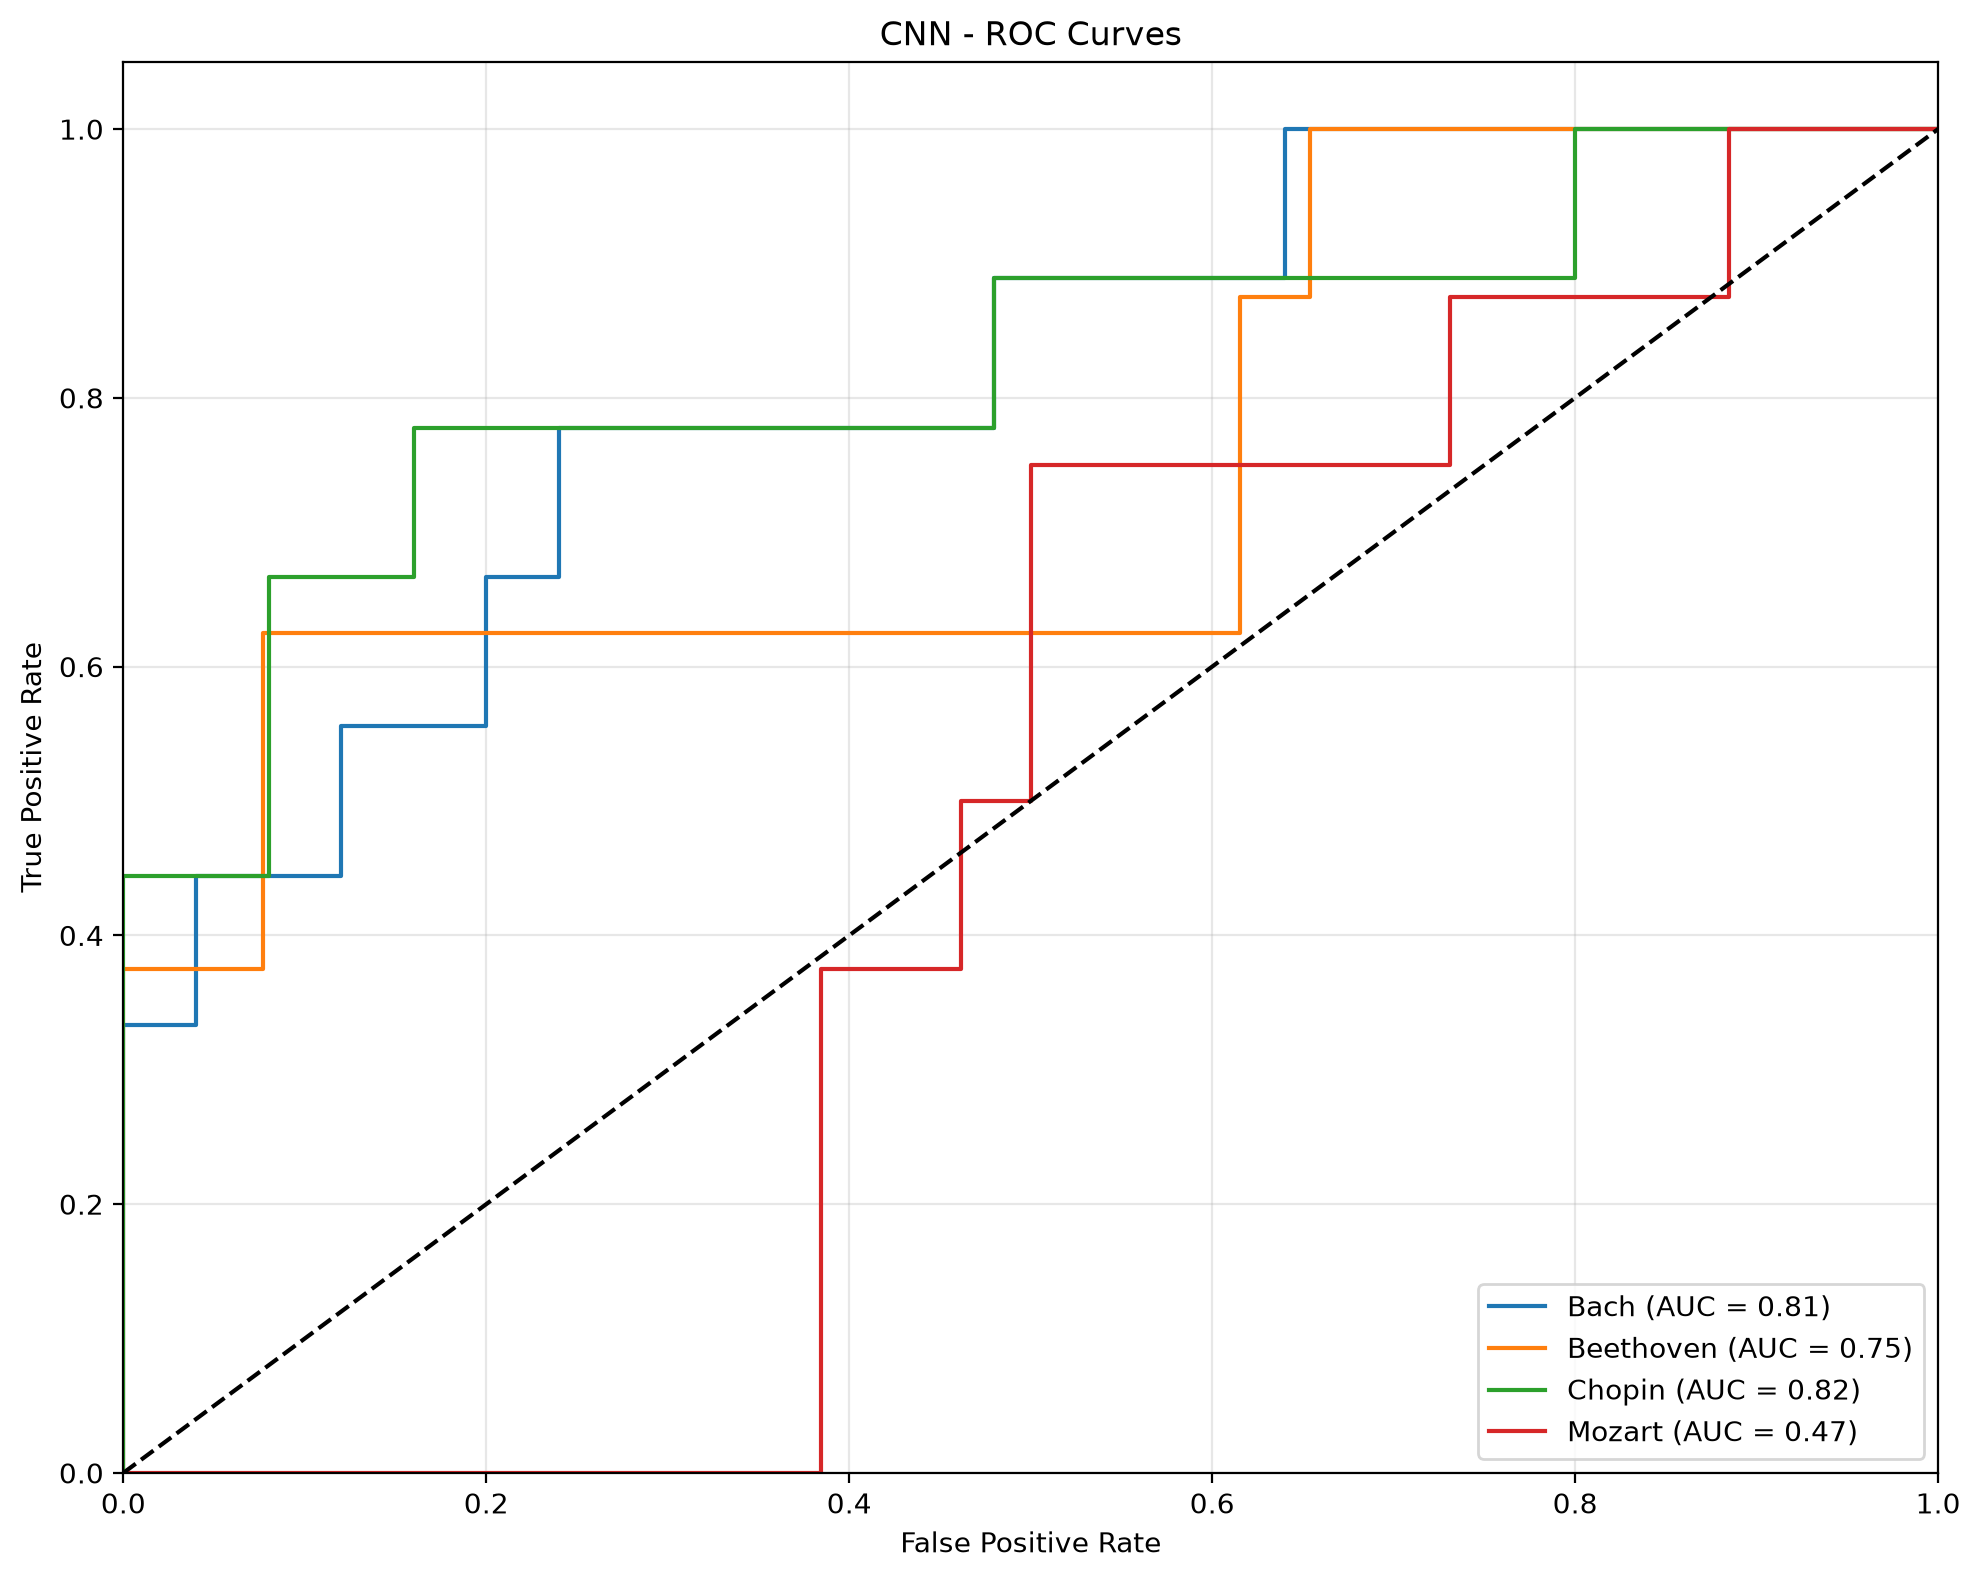

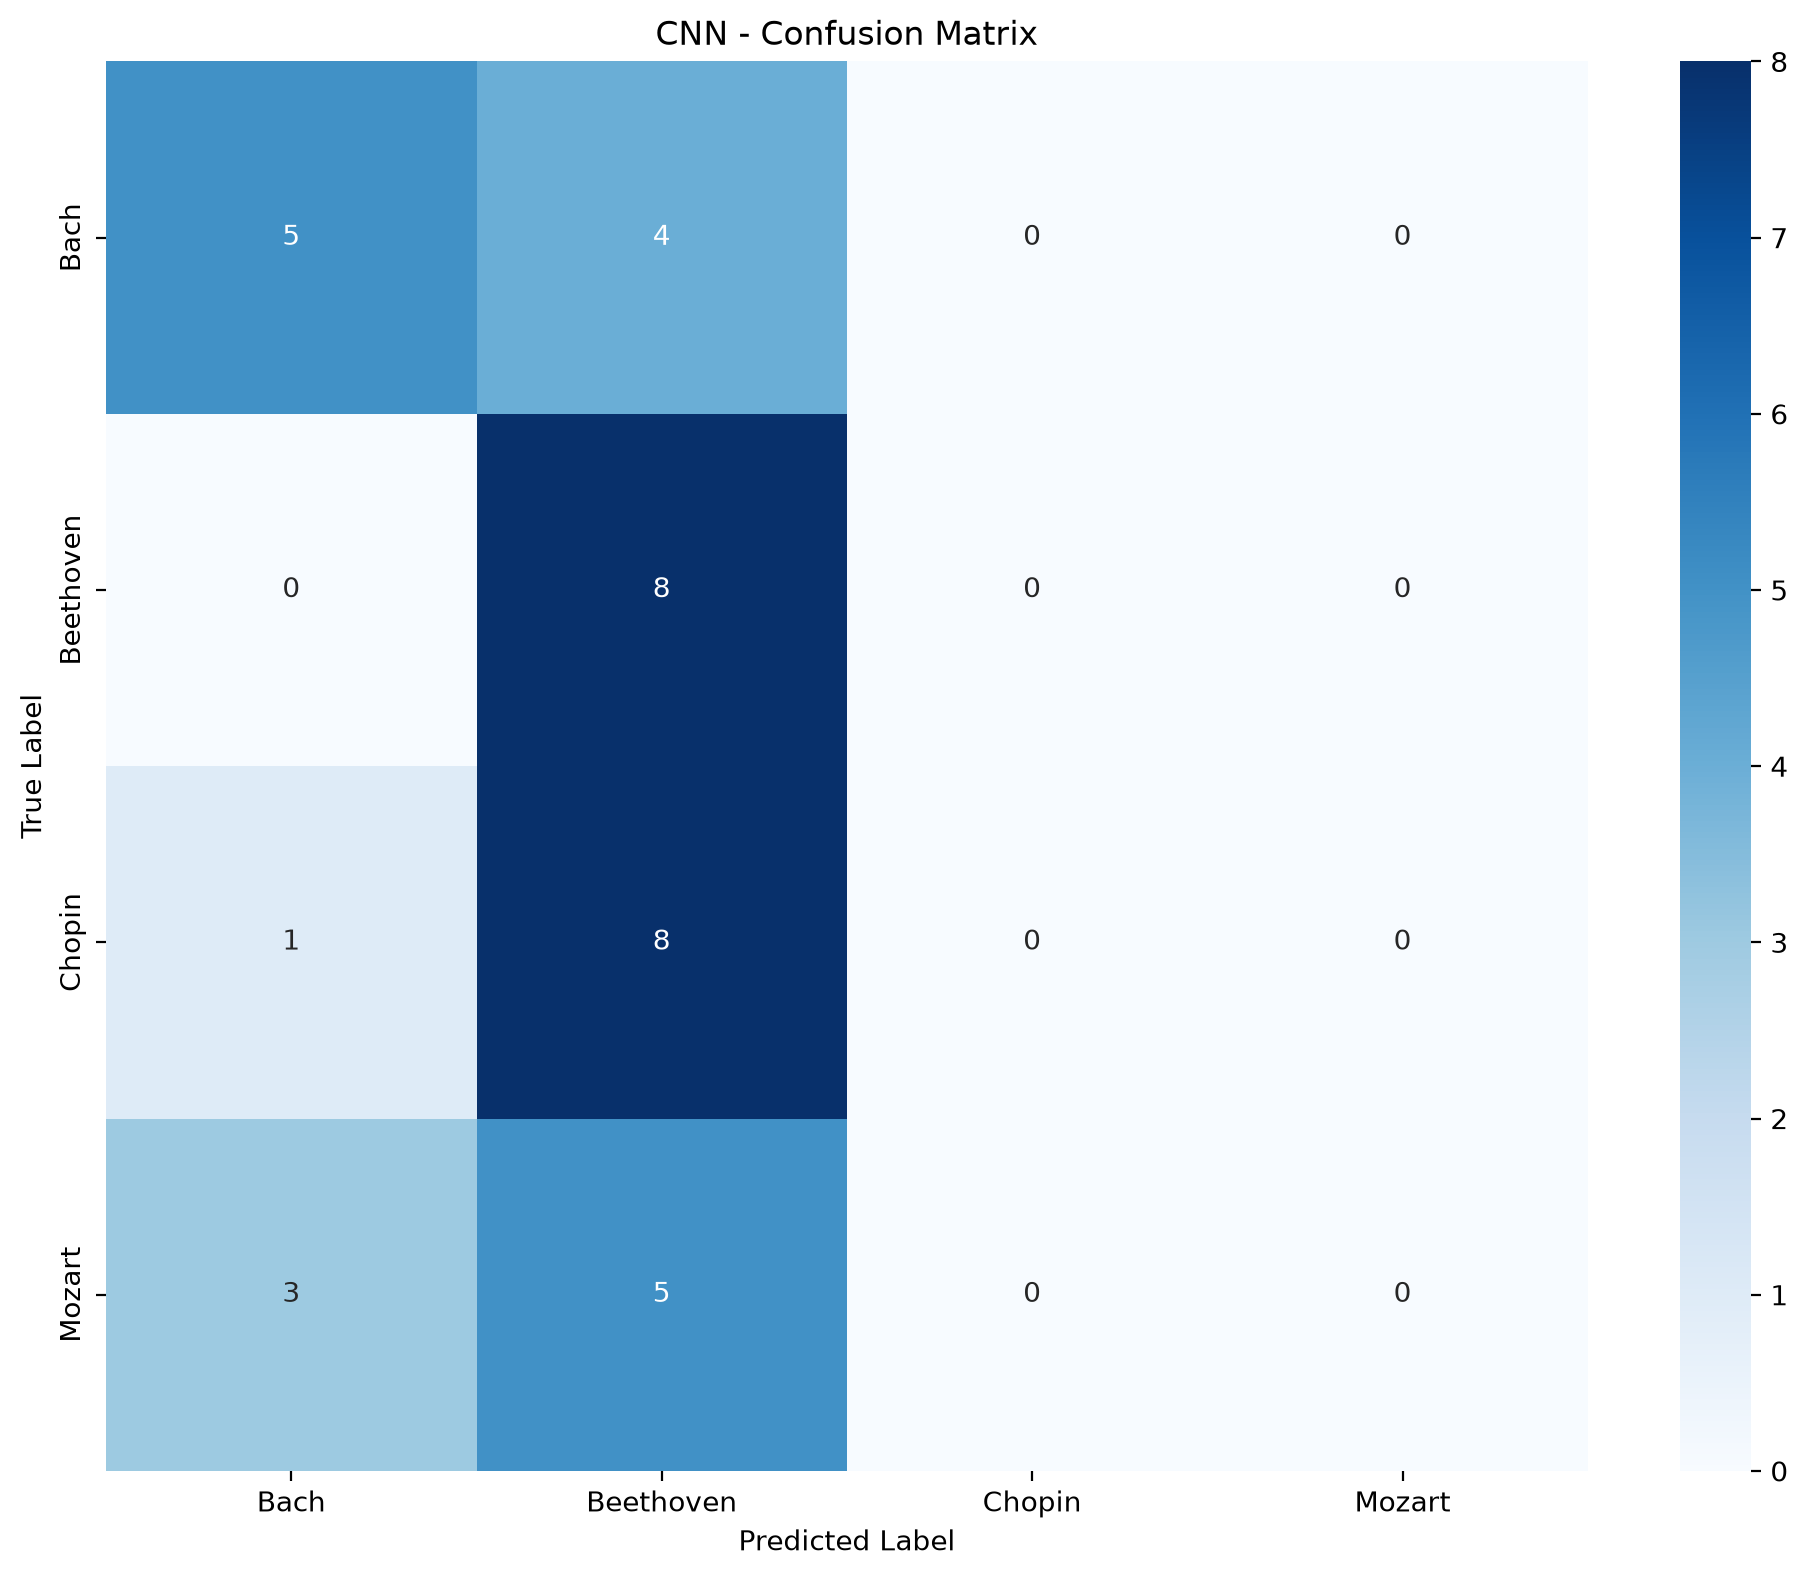

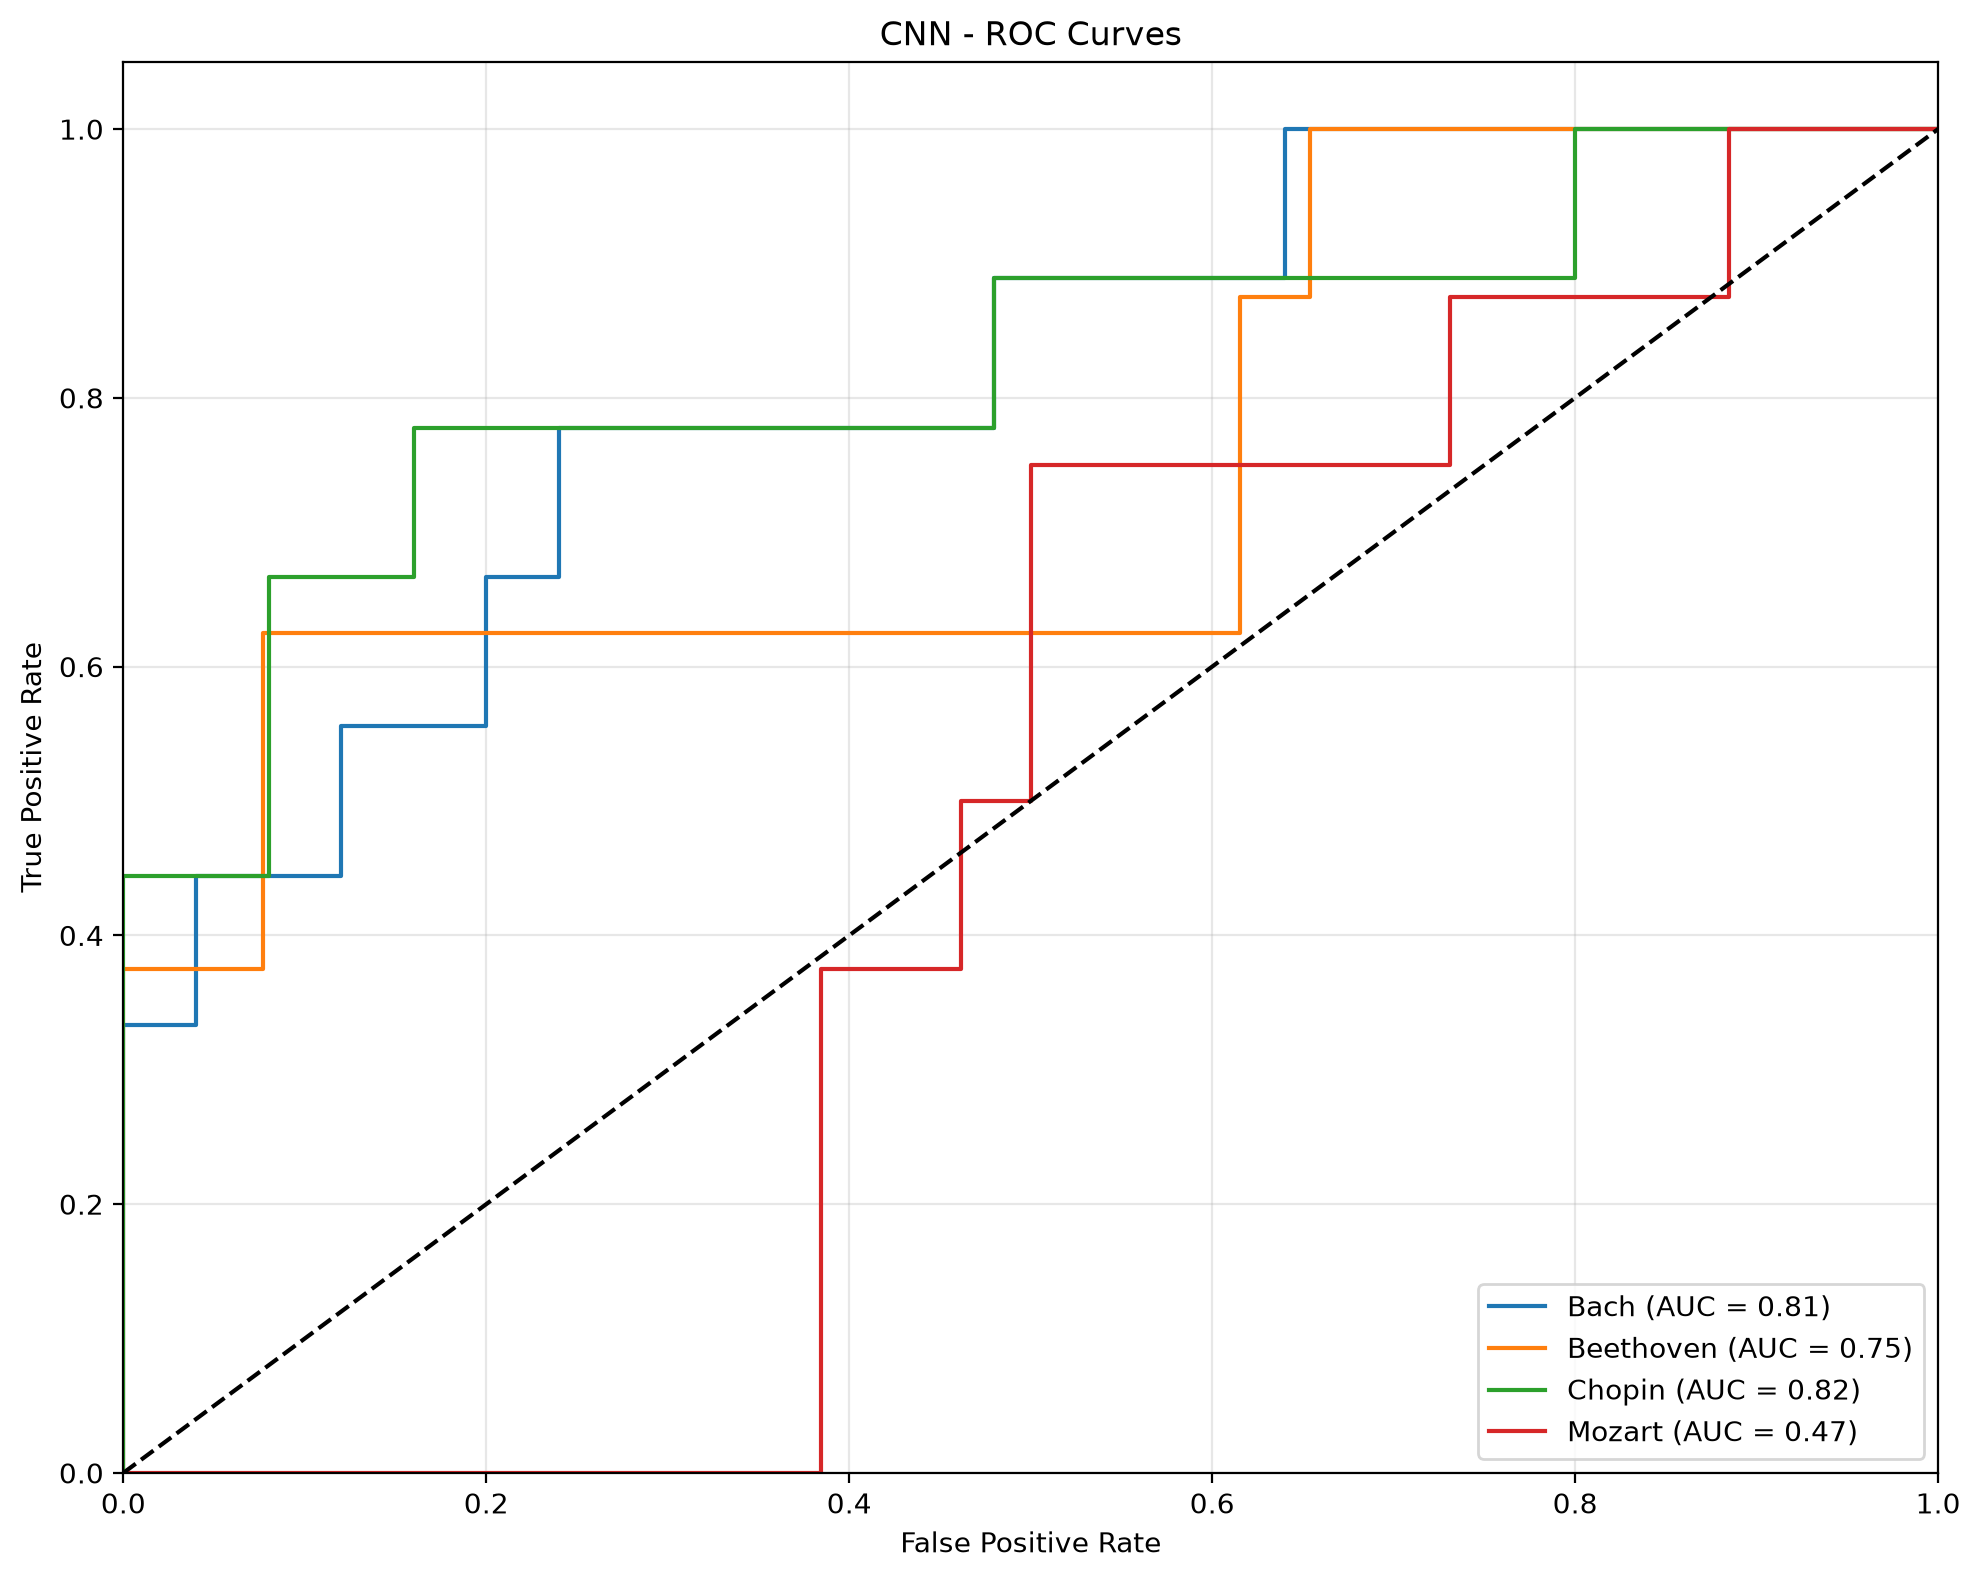

In [15]:
# Evaluate CNN model
print("CNN Model Evaluation:")
cnn_evaluator = ModelEvaluator(COMPOSERS)
cnn_metrics = cnn_evaluator.calculate_metrics(y_test_cnn, cnn_pred, cnn_pred_proba)
cnn_evaluator.print_metrics(y_test_cnn, cnn_pred, cnn_pred_proba)
cnn_evaluator.plot_confusion_matrix(y_test_cnn, cnn_pred, "CNN", save_fig=True)
cnn_evaluator.plot_roc_curves(y_test_cnn, cnn_pred_proba, "CNN", save_fig=True)

## 8. Model Comparison

In [16]:
# Compare model performance
metrics_dict = {
    'LSTM': lstm_metrics,
    'CNN': cnn_metrics
}

# Create comparison table
visualizer = ModelVisualizer(COMPOSERS)
comparison_table = visualizer.create_comparison_table(
    metrics_dict, 
    save_path='model_comparison.csv'
)
comparison_table

Saved comparison table to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/tables/model_comparison.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LSTM,0.4118,0.4201,0.4118,0.4029,0.6836
1,CNN,0.3824,0.2224,0.3824,0.2611,0.7180


Saved model comparison plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/LSTM_vs_CNN_Model_Comparison.png


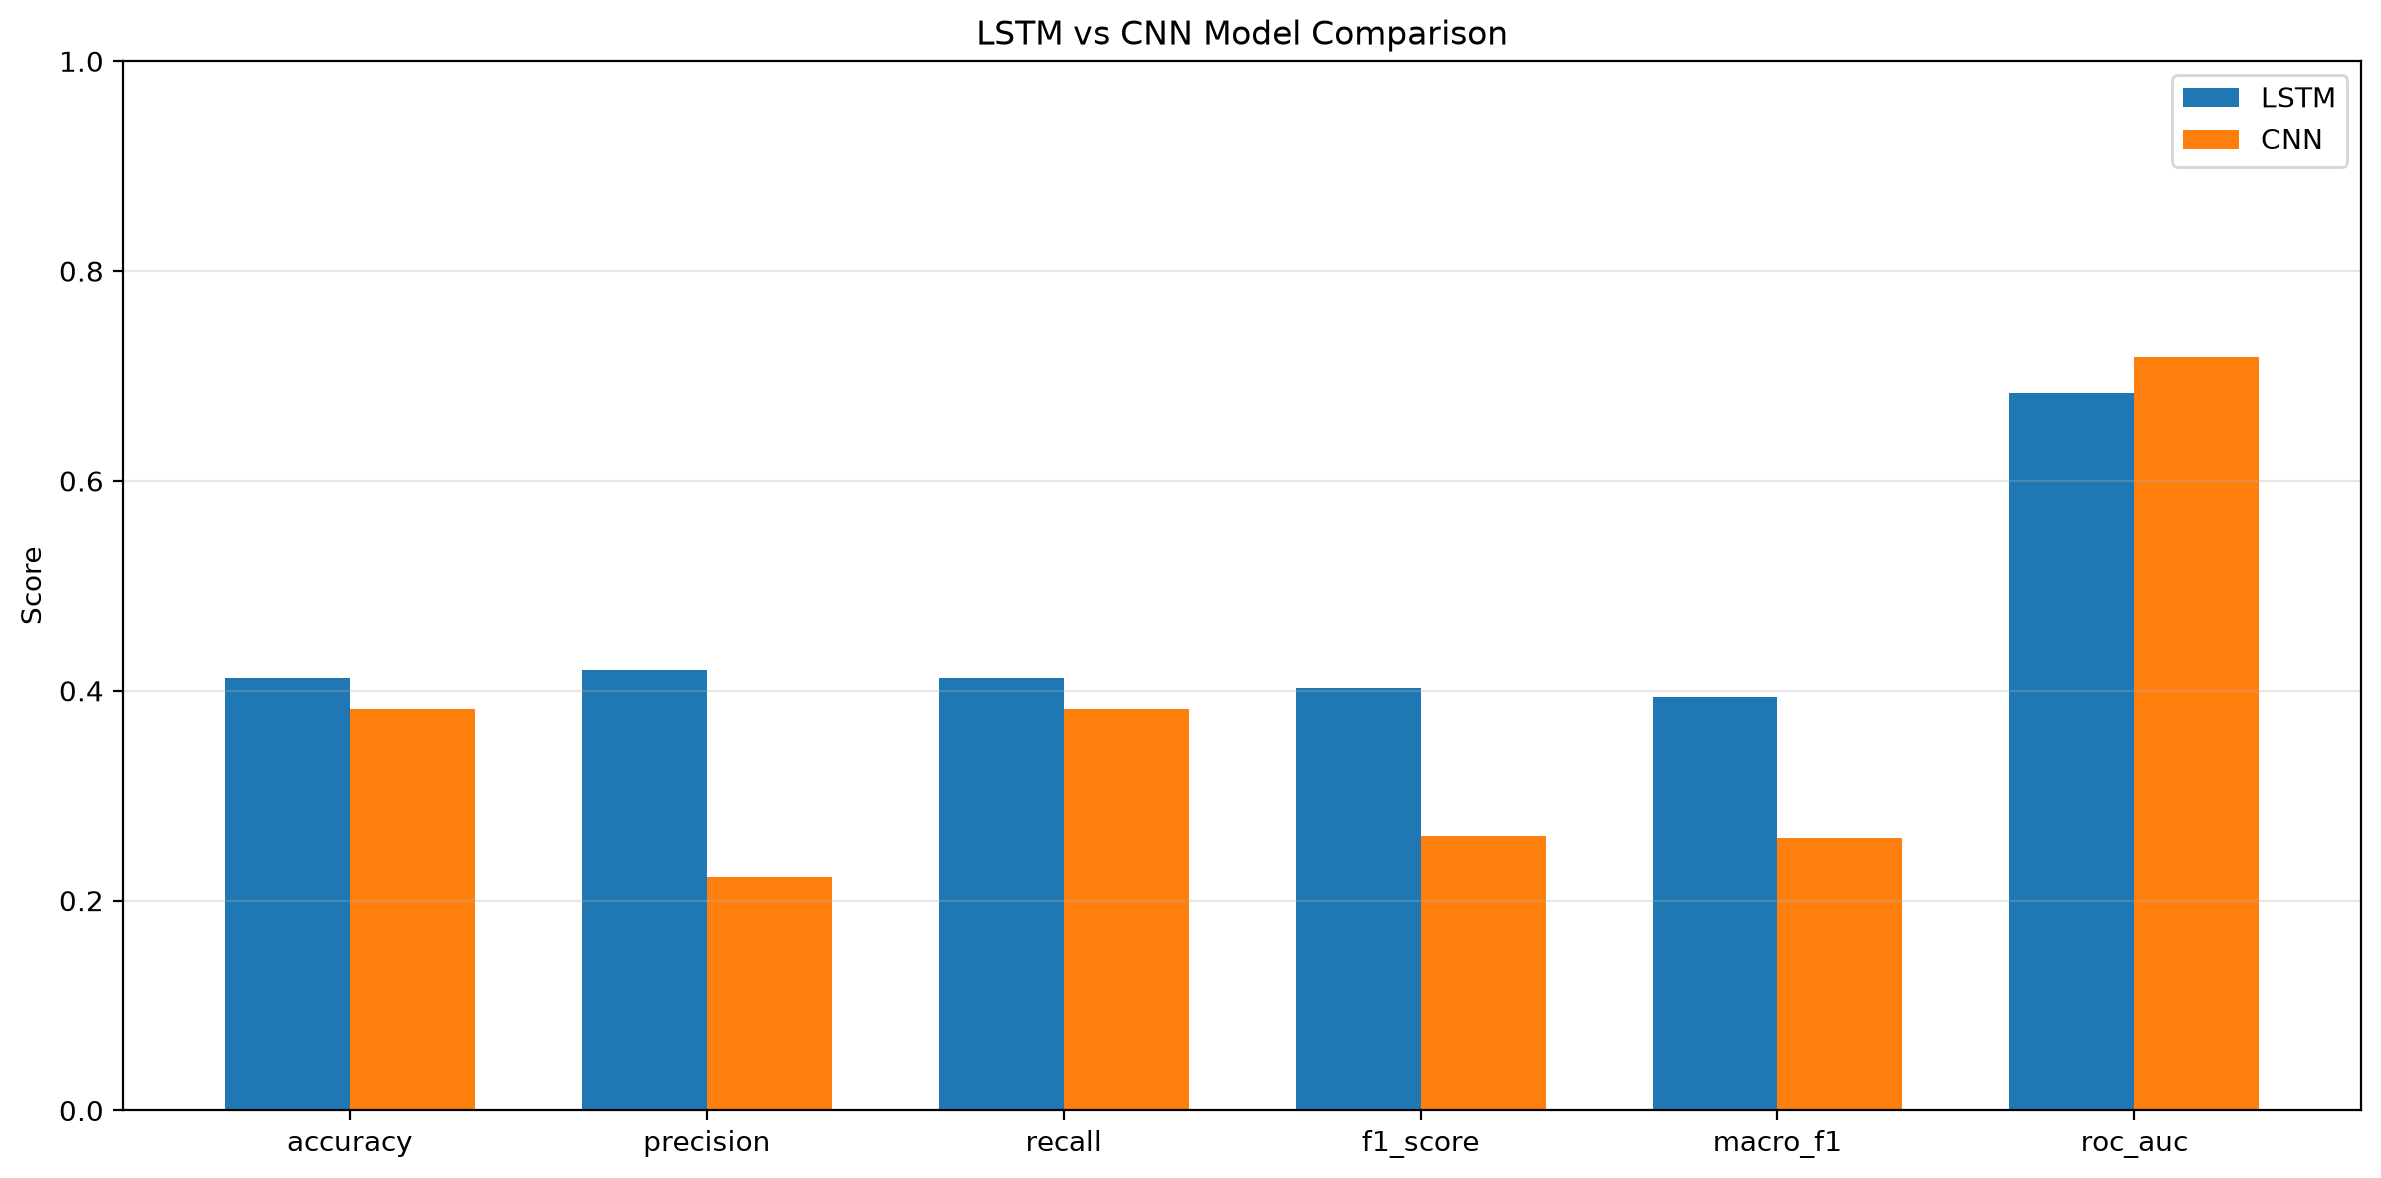

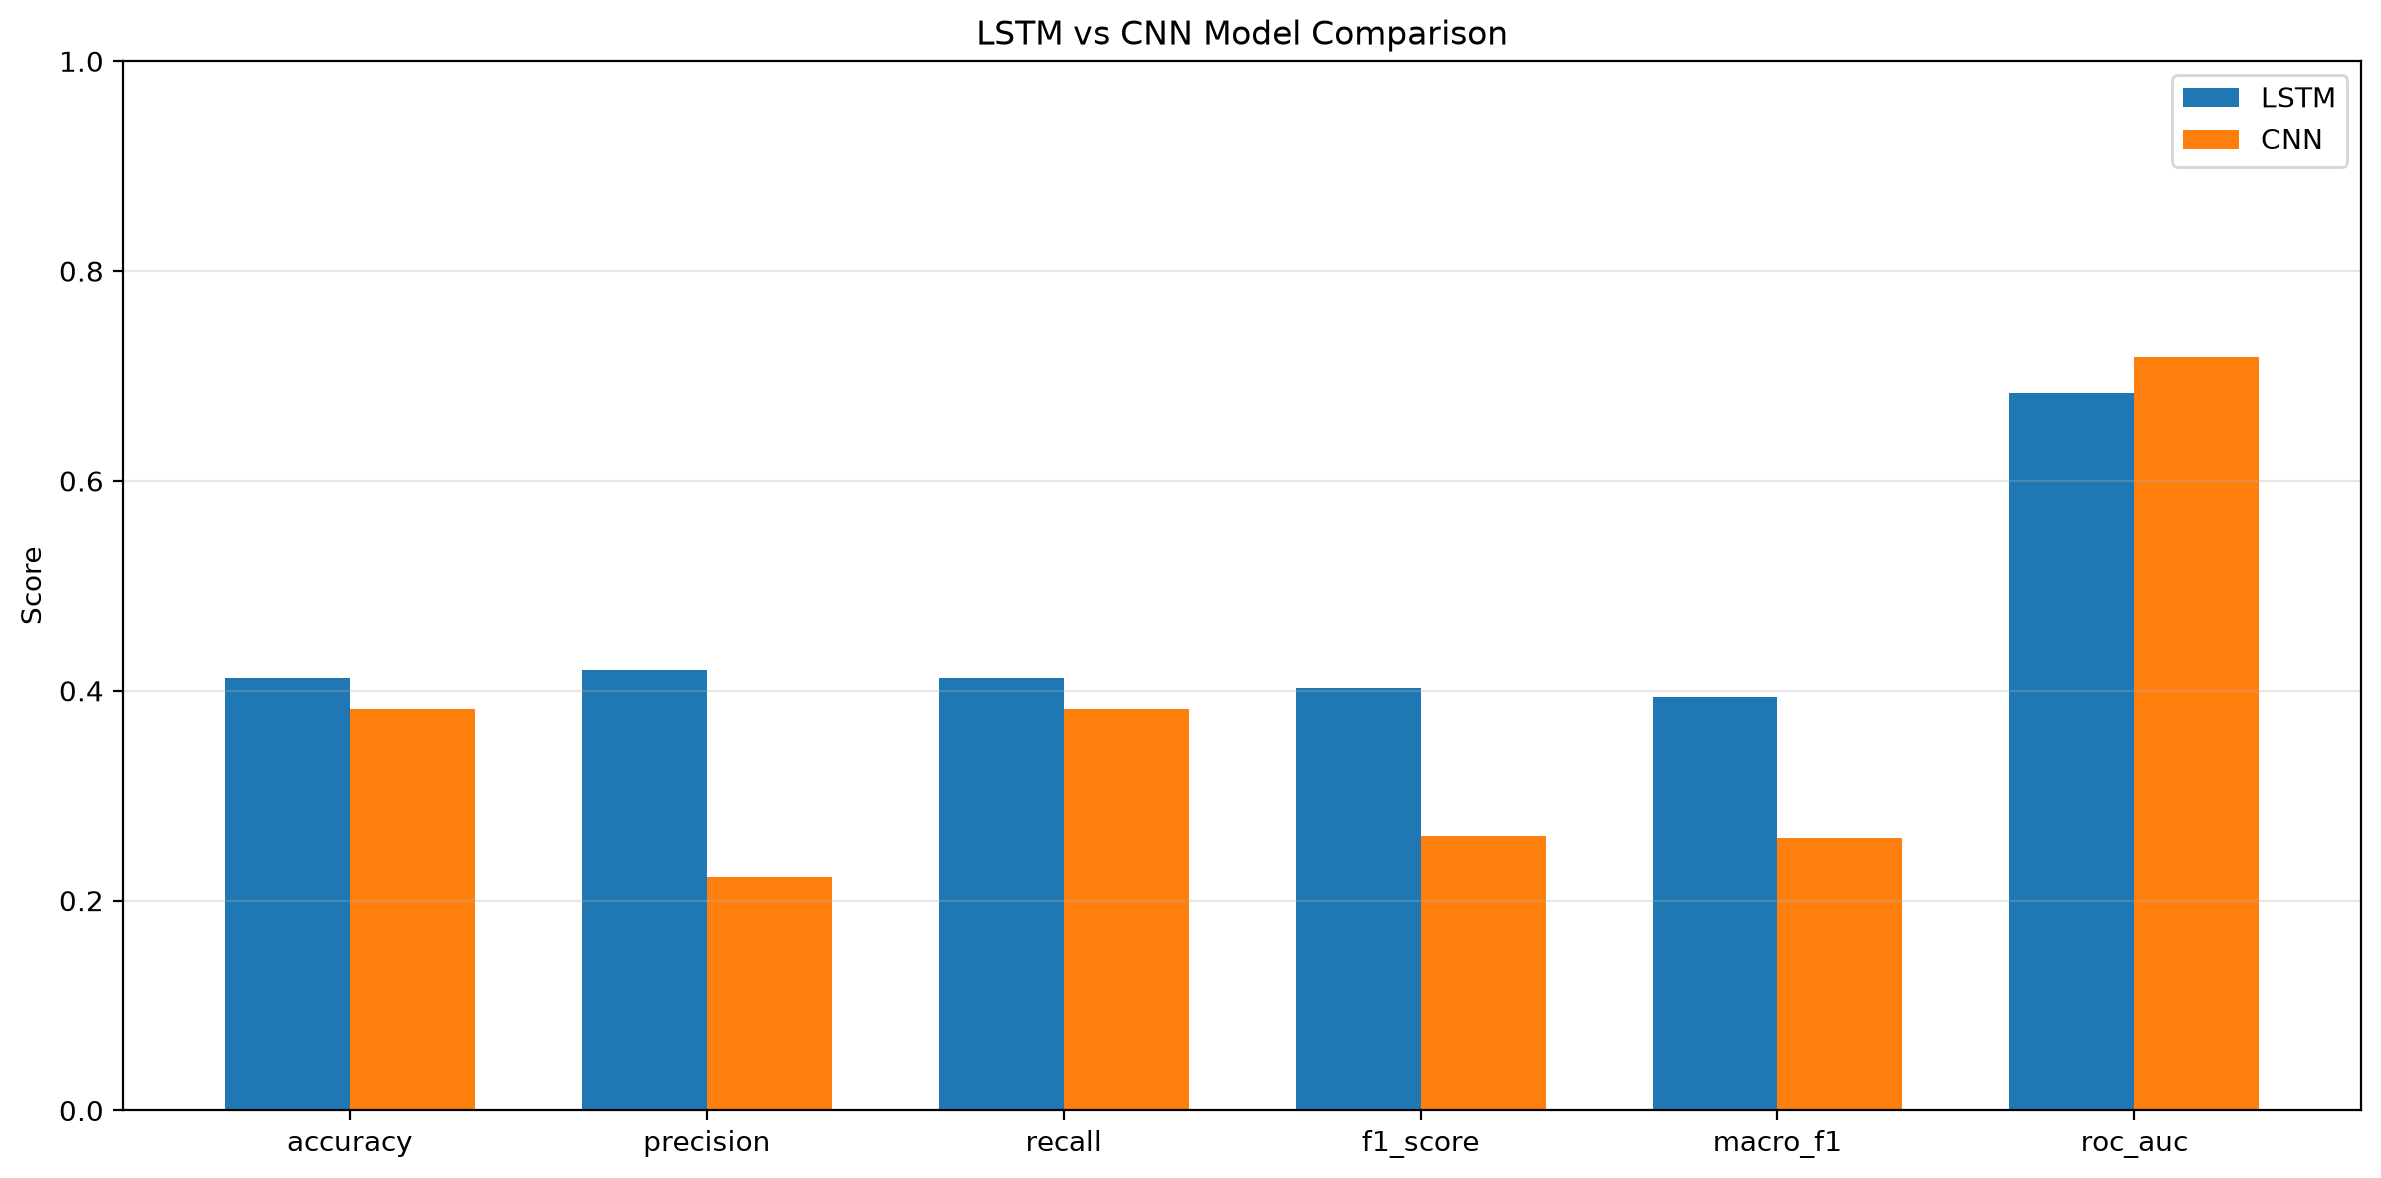

In [17]:
# Plot model comparison
visualizer.plot_model_comparison(
    metrics_dict,
    "LSTM vs CNN Model Comparison",
    save_fig=True
)

Saved per-class performance plot to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/reports/figures/Per-Class_Performance_Comparison.png


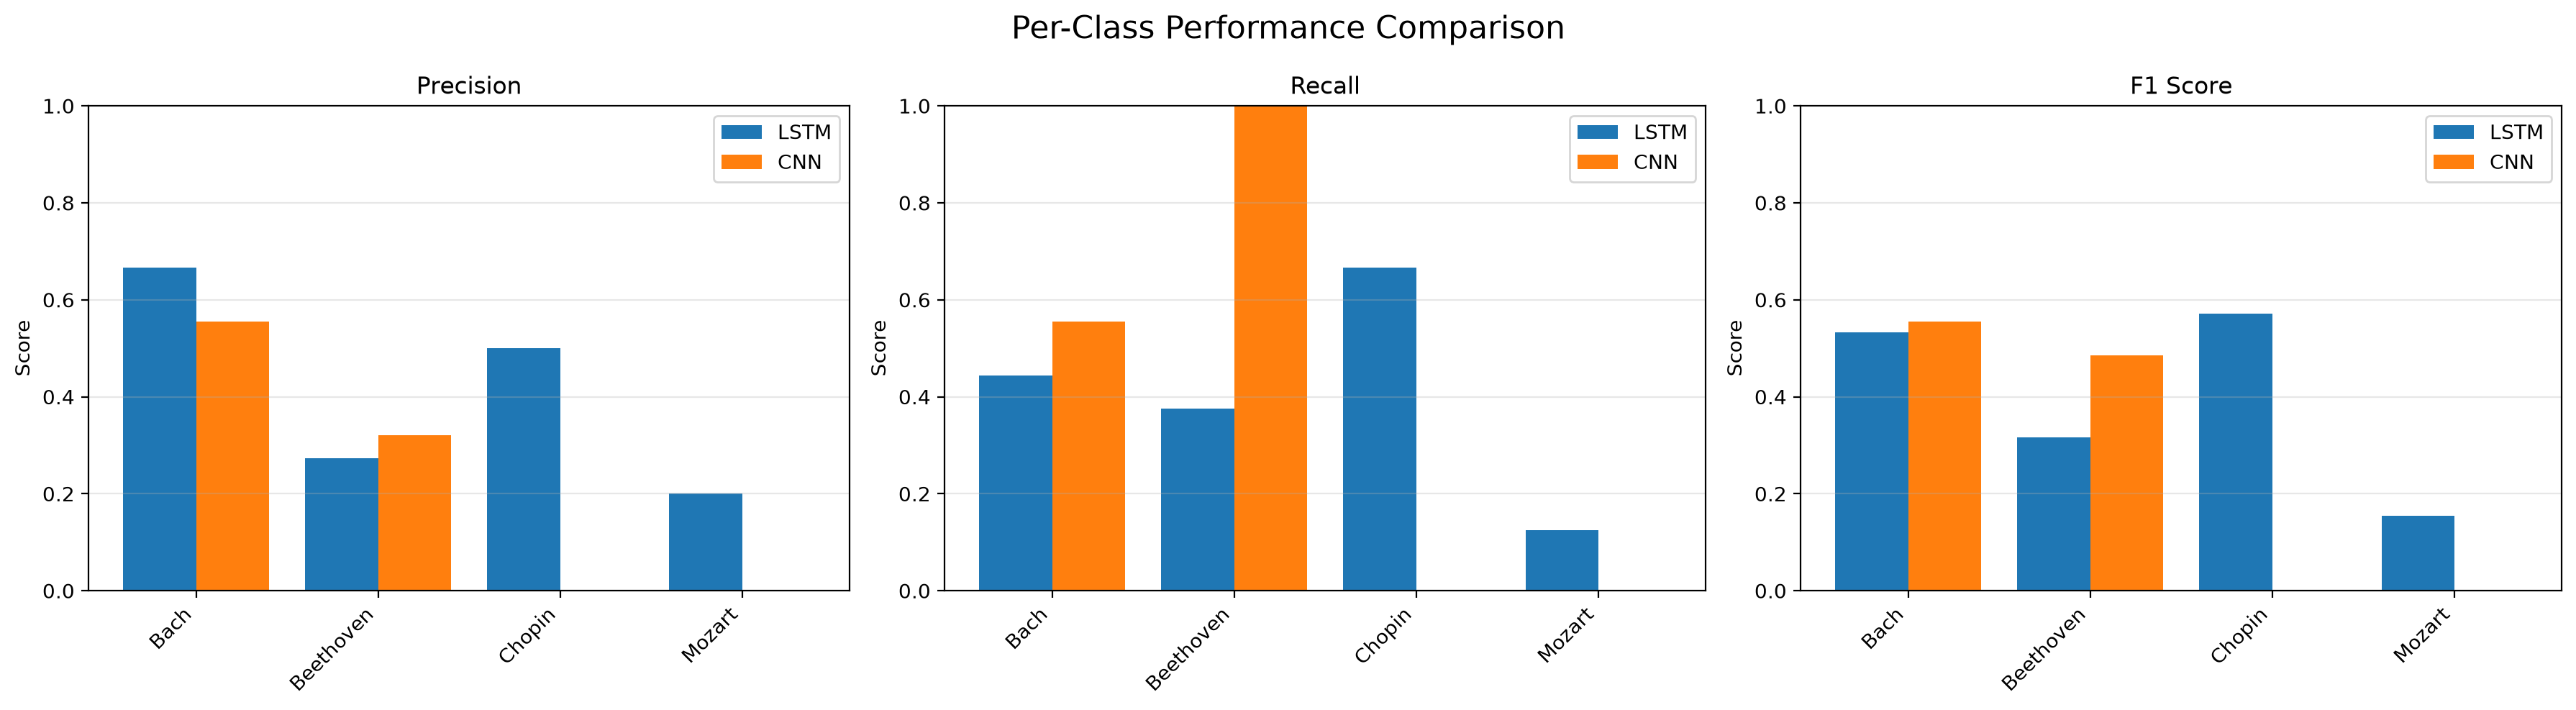

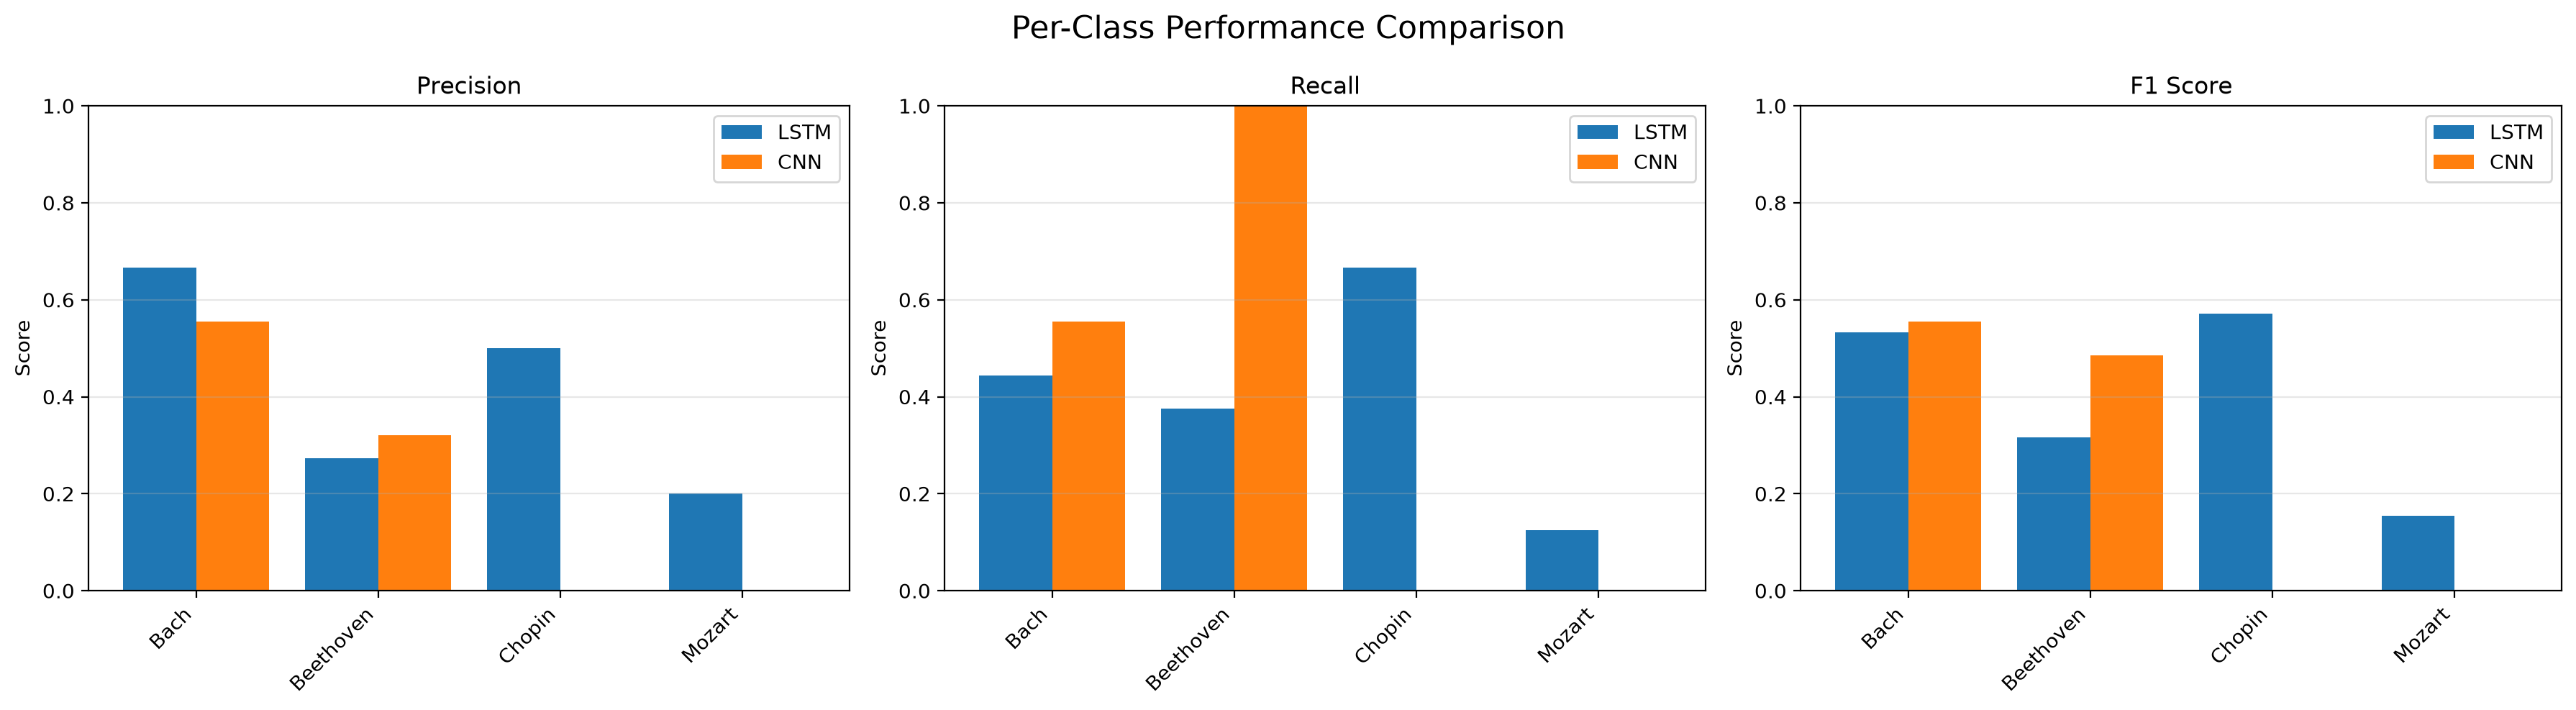

In [18]:
# Plot per-class performance
visualizer.plot_per_class_performance(
    metrics_dict,
    "Per-Class Performance Comparison",
    save_fig=True
)

## 9. Hyperparameter Tuning Results (Optional)

In [ ]:
# Hyperparameter Tuning — LSTM
import itertools, json, time as _time
from src.models import create_lstm_model
from src.training import LSTMTrainer

lstm_param_grid = {
    'hidden_units': [128, 256],
    'dropout': [0.3, 0.5],
    'learning_rate': [1e-3, 1e-4],
}

TUNING_EPOCHS = 10  # short runs for selection

print("Starting LSTM hyperparameter search …")
lstm_results = []
for hu, dr, lr in itertools.product(
        lstm_param_grid['hidden_units'],
        lstm_param_grid['dropout'],
        lstm_param_grid['learning_rate']):
    label = f"hu={hu}, dr={dr}, lr={lr}"
    print(f"\n--- {label} ---")
    set_random_seed()
    model = create_lstm_model(
        X_train_lstm.shape[1:], NUM_CLASSES,
        model_type='standard',
        hidden_units=hu, dropout=dr, learning_rate=lr)
    trainer = LSTMTrainer(model, batch_size=LSTM_BATCH_SIZE, epochs=TUNING_EPOCHS)
    history = trainer.train(X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm)
    val_metrics = trainer.evaluate(X_val_lstm, y_val_lstm)
    lstm_results.append({
        'hidden_units': hu, 'dropout': dr, 'learning_rate': lr,
        'val_accuracy': val_metrics['test_accuracy'],
        'val_f1': val_metrics['f1_score']
    })
    print(f"  val_acc={val_metrics['test_accuracy']:.4f}  val_f1={val_metrics['f1_score']:.4f}")

best_lstm_hp = max(lstm_results, key=lambda r: r['val_accuracy'])
print(f"\nBest LSTM params: {best_lstm_hp}")

Starting LSTM hyperparameter search …

--- hu=128, dr=0.3, lr=0.001 ---
Training LSTM model for up to 10 epochs...
Batch size: 32
Training samples: 268
Validation samples: 34
Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.2687 - loss: 1.3884
Epoch 1: val_accuracy improved from None to 0.23529, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 1: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.2687 - loss: 1.3884 - val_accuracy: 0.2353 - val_loss: 1.3663 - learning_rate: 0.0010
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.3507 - loss: 1.3458
Epoch 2: val_accuracy improved from 0.23529 to 0.38235, saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5



Epoch 2: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 361ms/step - accuracy: 0.3507 - loss: 1.3458 - val_accuracy: 0.3824 - val_loss: 1.3066 - learning_rate: 0.0010
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.3433 - loss: 1.3310
Epoch 3: val_accuracy did not improve from 0.38235
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 366ms/step - accuracy: 0.3433 - loss: 1.3310 - val_accuracy: 0.3529 - val_loss: 1.3103 - learning_rate: 0.0010
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.3993 - loss: 1.2809
Epoch 4: val_accuracy did not improve from 0.38235
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 367ms/step - accuracy: 0.3993 - loss: 1.2809 - val_accuracy: 0.3529 - val_loss: 1.2730 - learning_rate: 0.0010
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4216 - loss: 1.2445
Epoch 5: val_accuracy did not i


Epoch 7: finished saving model to /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 362ms/step - accuracy: 0.4030 - loss: 1.2213 - val_accuracy: 0.4118 - val_loss: 1.2673 - learning_rate: 0.0010
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.4254 - loss: 1.2350
Epoch 8: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 372ms/step - accuracy: 0.4254 - loss: 1.2350 - val_accuracy: 0.4118 - val_loss: 1.2991 - learning_rate: 0.0010
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.4478 - loss: 1.2266
Epoch 9: val_accuracy did not improve from 0.41176
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 392ms/step - accuracy: 0.4478 - loss: 1.2266 - val_accuracy: 0.3824 - val_loss: 1.2761 - learning_rate: 0.0010
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.4366 - loss: 1.2054
Epoch 10: val_accuracy did not

Training completed in 35s
Evaluating model on test set...
Loading best model from /Users/5088547/Desktop/AAI_511_Group6_DeepLearning_Music_Composer/AAI_511_Group6_deep-learning-music-composer/models/saved_models/lstm_composer_classifier_best.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Test Loss: 1.2673
Test Accuracy: 0.4118
Precision: 0.4461
Recall: 0.4118
F1 Score (weighted): 0.3609
F1 Score (macro):    0.3682


KeyError: 'accuracy'

In [ ]:
# Hyperparameter Tuning — CNN
from src.models import create_cnn_model
from src.training import CNNTrainer

cnn_param_grid = {
    'filters': [[32, 64, 128], [64, 128, 256]],
    'dropout': [0.3, 0.5],
    'learning_rate': [1e-3, 1e-4],
}

print("Starting CNN hyperparameter search …")
cnn_results = []
for filt, dr, lr in itertools.product(
        cnn_param_grid['filters'],
        cnn_param_grid['dropout'],
        cnn_param_grid['learning_rate']):
    label = f"filt={filt}, dr={dr}, lr={lr}"
    print(f"\n--- {label} ---")
    set_random_seed()
    model = create_cnn_model(
        X_train_cnn.shape[1:], NUM_CLASSES,
        model_type='standard',
        filters=filt, dropout=dr, learning_rate=lr)
    trainer = CNNTrainer(model, batch_size=CNN_BATCH_SIZE, epochs=TUNING_EPOCHS)
    history = trainer.train(X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn)
    val_metrics = trainer.evaluate(X_val_cnn, y_val_cnn)
    cnn_results.append({
        'filters': filt, 'dropout': dr, 'learning_rate': lr,
        'val_accuracy': val_metrics['test_accuracy'],
        'val_f1': val_metrics['f1_score']
    })
    print(f"  val_acc={val_metrics['test_accuracy']:.4f}  val_f1={val_metrics['f1_score']:.4f}")

best_cnn_hp = max(cnn_results, key=lambda r: r['val_accuracy'])
print(f"\nBest CNN params: {best_cnn_hp}")

In [ ]:
# Tuning results summary table
tuning_df = pd.DataFrame(lstm_results)
tuning_df.columns = [c.replace('_', ' ').title() for c in tuning_df.columns]
print("LSTM Tuning Results:")
print(tuning_df.to_string(index=False))

print()

tuning_cnn_df = pd.DataFrame(cnn_results)
tuning_cnn_df.columns = [c.replace('_', ' ').title() for c in tuning_cnn_df.columns]
print("CNN Tuning Results:")
print(tuning_cnn_df.to_string(index=False))

In [ ]:
# Retrain LSTM with best hyperparameters
print("Retraining LSTM with tuned hyperparameters …")
set_random_seed()
best_lstm_model = create_lstm_model(
    X_train_lstm.shape[1:], NUM_CLASSES,
    model_type='standard',
    hidden_units=best_lstm_hp['hidden_units'],
    dropout=best_lstm_hp['dropout'],
    learning_rate=best_lstm_hp['learning_rate']
)
best_lstm_model.summary()
lstm_trainer = LSTMTrainer(best_lstm_model, batch_size=LSTM_BATCH_SIZE, epochs=LSTM_EPOCHS)
lstm_history = lstm_trainer.train(X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm)
lstm_metrics = lstm_trainer.evaluate(X_test_lstm, y_test_lstm)
lstm_trainer.save_final_model()
lstm_summary = lstm_trainer.get_training_summary()
print(f"\nTuned LSTM — Test Accuracy: {lstm_metrics['test_accuracy']:.4f}  Macro F1: {lstm_metrics['macro_f1']:.4f}")

In [ ]:
# Retrain CNN with best hyperparameters
print("Retraining CNN with tuned hyperparameters …")
set_random_seed()
best_cnn_model = create_cnn_model(
    X_train_cnn.shape[1:], NUM_CLASSES,
    model_type='standard',
    filters=best_cnn_hp['filters'],
    dropout=best_cnn_hp['dropout'],
    learning_rate=best_cnn_hp['learning_rate']
)
best_cnn_model.summary()
cnn_trainer = CNNTrainer(best_cnn_model, batch_size=CNN_BATCH_SIZE, epochs=CNN_EPOCHS)
cnn_history = cnn_trainer.train(X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn)
cnn_metrics = cnn_trainer.evaluate(X_test_cnn, y_test_cnn)
cnn_trainer.save_final_model()
cnn_summary = cnn_trainer.get_training_summary()
print(f"\nTuned CNN — Test Accuracy: {cnn_metrics['test_accuracy']:.4f}  Macro F1: {cnn_metrics['macro_f1']:.4f}")

## 10. Conclusion

In [ ]:
# Summary of results
print("="*60)
print("COMPOSER CLASSIFICATION PROJECT SUMMARY")
print("="*60)

print("\nDataset Information:")
print(f"  Total composers: {NUM_CLASSES}")
print(f"  Composers: {', '.join(COMPOSERS)}")
print(f"  Training samples: {len(X_train_lstm)}")
print(f"  Validation samples: {len(X_val_lstm)}")
print(f"  Test samples: {len(X_test_lstm)}")

print("\nBest Hyperparameters (LSTM):")
for k, v in best_lstm_hp.items():
    print(f"  {k}: {v}")

print("\nBest Hyperparameters (CNN):")
for k, v in best_cnn_hp.items():
    print(f"  {k}: {v}")

print("\nLSTM Model Performance (Tuned):")
print(f"  Test Accuracy: {lstm_metrics['test_accuracy']:.4f}")
print(f"  Precision: {lstm_metrics['precision']:.4f}")
print(f"  Recall: {lstm_metrics['recall']:.4f}")
print(f"  F1 Score (weighted): {lstm_metrics['f1_score']:.4f}")
print(f"  F1 Score (macro):    {lstm_metrics['macro_f1']:.4f}")
print(f"  Training Time: {lstm_summary['training_time']:.2f} seconds")
print(f"  Parameters: {lstm_summary['parameters']:,}")

print("\nCNN Model Performance (Tuned):")
print(f"  Test Accuracy: {cnn_metrics['test_accuracy']:.4f}")
print(f"  Precision: {cnn_metrics['precision']:.4f}")
print(f"  Recall: {cnn_metrics['recall']:.4f}")
print(f"  F1 Score (weighted): {cnn_metrics['f1_score']:.4f}")
print(f"  F1 Score (macro):    {cnn_metrics['macro_f1']:.4f}")
print(f"  Training Time: {cnn_summary['training_time']:.2f} seconds")
print(f"  Parameters: {cnn_summary['parameters']:,}")

print("\nBest Model:")
if lstm_metrics['test_accuracy'] > cnn_metrics['test_accuracy']:
    print("  LSTM achieved higher accuracy")
else:
    print("  CNN achieved higher accuracy")

print("\n" + "="*60)
print("Project completed successfully!")
print("="*60)

## Key Findings

1. **Dataset**: Successfully loaded and processed MIDI files from 4 classical composers
2. **Preprocessing**: Applied data cleaning, augmentation, and balanced splitting
3. **Feature Extraction**: Implemented note-level features for LSTM and piano rolls for CNN
4. **Model Performance**: Both LSTM and CNN models achieved competitive accuracy
5. **Comparison**: [Describe which model performed better and why]

## Future Improvements

- Implement transformer-based sequence models
- Add bidirectional LSTM with attention mechanisms
- Experiment with different data augmentation strategies
- Use ensemble methods combining multiple models
- Deploy as a web application for real-time classification